# Predicting Diabetes Diagnosis from Lifestyle and Clinical Screening Data

**Can we predict whether a person has been diagnosed with diabetes, using demographic, lifestyle, and routine clinical screening measurements?**

Problem type: Binary Classification

## Dataset Features Reference

| # | Column | Description |
|---|---|---|
| 1 | `age` | Age of the individual (years). |
| 2 | `gender` | Male / Female / Other. |
| 3 | `ethnicity` | Self-reported ethnicity group. |
| 4 | `education_level` | Highest level of education completed. |
| 5 | `income_level` | Household income bracket. |
| 6 | `employment_status` | Current employment status. |
| 7 | `smoking_status` | Never / Former / Current smoker. |
| 8 | `alcohol_consumption_per_week` | Number of alcoholic drinks per week. |
| 9 | `physical_activity_minutes_per_week` | Minutes of physical activity per week. |
| 10 | `diet_score` | Self-reported diet quality score (0-10). |
| 11 | `sleep_hours_per_day` | Average hours of sleep per day. |
| 12 | `screen_time_hours_per_day` | Average hours of screen time per day. |
| 13 | `family_history_diabetes` | 1 if a family member has diabetes, else 0. |
| 14 | `hypertension_history` | 1 if diagnosed with hypertension, else 0. |
| 15 | `cardiovascular_history` | 1 if diagnosed with cardiovascular disease, else 0. |
| 16 | `bmi` | Body Mass Index. |
| 17 | `waist_to_hip_ratio` | Waist circumference / hip circumference. |
| 18 | `systolic_bp` | Systolic blood pressure (mmHg). |
| 19 | `diastolic_bp` | Diastolic blood pressure (mmHg). |
| 20 | `heart_rate` | Resting heart rate (bpm). |
| 21 | `cholesterol_total` | Total cholesterol (mg/dL). |
| 22 | `hdl_cholesterol` | HDL ("good") cholesterol (mg/dL). |
| 23 | `ldl_cholesterol` | LDL ("bad") cholesterol (mg/dL). |
| 24 | `triglycerides` | Triglycerides level (mg/dL). |
| 25 | `glucose_fasting` | Fasting blood glucose (mg/dL). |
| 26 | `glucose_postprandial` | Post-meal (2-hour) blood glucose (mg/dL). |
| 27 | `insulin_level` | Fasting insulin level (uIU/mL). |
| 28 | `hba1c` | HbA1c — average blood glucose control over ~3 months (%). |
| 29 | `diabetes_risk_score` | A composite pre-computed risk score. |
| 30 | `diabetes_stage` | Clinical stage: No Diabetes / Pre-Diabetes / Type 1 / Type 2 / Gestational. **Excluded from features — see Part 5.** |
| 31 | `diagnosed_diabetes` | **Target variable.** 1 = diagnosed with diabetes, 0 = not diagnosed. |

# Part 1 – Problem and Dataset Understanding

**1. What is the purpose of the dataset?**
It provides demographic, lifestyle, and clinical screening measurements for 100,000 individuals, together with whether each person has been diagnosed with diabetes. It is designed to study which everyday and clinical factors are associated with a diabetes diagnosis.

**2. What real-world problem are you trying to solve?**
Diabetes is frequently under-diagnosed until complications appear. A model that flags high-risk individuals from routine screening data (the kind collected in an annual check-up) could support earlier referral for formal testing — a triage/screening tool, not a diagnostic replacement.

**3. What does each row represent?**
One individual (one person, one screening record) — not a repeated encounter like a hospital visit dataset.

**4. How many rows and columns are there?**
100,000 rows × 31 columns (30 features + 1 target), before cleaning.

**5. Which features are numerical?**
`age`, `alcohol_consumption_per_week`, `physical_activity_minutes_per_week`, `diet_score`, `sleep_hours_per_day`, `screen_time_hours_per_day`, `bmi`, `waist_to_hip_ratio`, `systolic_bp`, `diastolic_bp`, `heart_rate`, `cholesterol_total`, `hdl_cholesterol`, `ldl_cholesterol`, `triglycerides`, `glucose_fasting`, `glucose_postprandial`, `insulin_level`, `hba1c`, `diabetes_risk_score`. (`family_history_diabetes`, `hypertension_history`, `cardiovascular_history` are stored as 0/1 integers but are conceptually binary categorical flags.)

**6. Which features are categorical?**
`gender`, `ethnicity`, `education_level`, `income_level`, `employment_status`, `smoking_status`, plus the three 0/1 flags above treated as categorical, plus `diabetes_stage` (excluded — see Part 5).

**7. What is the target variable?**
`diagnosed_diabetes` (binary: 1 = diagnosed, 0 = not diagnosed).

**8. Is the problem Classification or Regression?**
Classification (binary).

**9. What are your input features X?**
All columns except `diagnosed_diabetes` and `diabetes_stage`. `diabetes_stage` is excluded because it directly encodes the diagnosis outcome (data leakage — quantified in Part 5).

**10. What is your target y?**
`diagnosed_diabetes`.

**11. Why is Machine Learning appropriate for this problem?**
The relationship between lifestyle/clinical factors and a diabetes diagnosis is multi-dimensional and not reducible to a single threshold rule (unlike, say, `hba1c >= 6.5`) once we mix in demographic and lifestyle variables. ML can combine many weak signals into a single risk estimate and can be re-evaluated as new data arrives.

**12. What would a useful prediction mean in the real-world context?**
A useful model would correctly flag most people who are actually diabetic (high recall on the positive class) so they get referred for proper testing, while keeping false alarms low enough that the screening tool stays trustworthy and cost-effective to act on.

# Part 2 – Initial Data Exploration

In [16]:
# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
RANDOM_STATE = 42

In [17]:
from pathlib import Path

# Works both locally (GitHub/Jupyter) and in Colab if the file is uploaded manually.
data_path = Path("../data/diabetes_dataset.csv")
if not data_path.exists():
    data_path = Path("data/diabetes_dataset.csv")
if not data_path.exists():
    data_path = Path("/content/diabetes-dataset.csv")

df = pd.read_csv(data_path)
print("Loaded from:", data_path)
print("Shape:", df.shape)
df.head(10)

Shape: (100000, 31)


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,7.9,7.9,0,0,0,30.5,0.89,134,78,68,239,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,6.5,8.7,0,0,0,23.1,0.80,129,76,67,116,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,10.0,8.1,1,0,0,22.2,0.81,115,73,74,213,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,6.6,5.2,0,0,0,26.8,0.88,120,93,68,171,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,7.4,5.0,0,0,0,21.2,0.78,92,67,67,210,52,125,160,137,184,12.74,7.20,23.5,Type 2,1
5,46,Female,White,Highschool,Upper-Middle,Employed,Never,2,124,9.0,6.2,5.4,0,0,0,26.1,0.85,95,81,57,218,61,119,179,100,133,8.77,6.03,23.5,Pre-Diabetes,0
6,75,Female,White,Graduate,Upper-Middle,Retired,Never,0,53,9.2,7.8,8.0,0,1,0,25.1,0.88,129,77,81,238,46,161,155,101,100,10.14,5.24,36.1,Pre-Diabetes,0
7,62,Male,White,Postgraduate,Middle,Unemployed,Current,1,75,4.1,9.0,12.9,0,1,1,23.9,0.86,128,83,76,241,49,159,120,110,189,8.96,7.04,34.2,Type 2,1
8,42,Male,Black,Highschool,Lower-Middle,Employed,Current,1,114,6.7,8.5,8.5,0,0,1,24.7,0.84,103,71,72,187,33,132,98,116,172,5.70,6.90,26.7,Type 2,1
9,59,Female,White,Graduate,Middle,Employed,Current,3,86,8.2,5.3,7.4,0,0,0,26.7,0.81,124,81,70,188,52,103,104,76,109,4.49,4.99,30.0,No Diabetes,0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day  

In [19]:
df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
age,100000.0,50.120410,15.604600,18.00,39.00,50.00,61.00,90.00
alcohol_consumption_per_week,100000.0,2.003670,1.417779,0.00,1.00,2.00,3.00,10.00
physical_activity_minutes_per_week,100000.0,118.911640,84.409662,0.00,57.00,100.00,160.00,833.00
diet_score,100000.0,5.994787,1.780954,0.00,4.80,6.00,7.20,10.00
sleep_hours_per_day,100000.0,6.997818,1.094622,3.00,6.30,7.00,7.70,10.00
screen_time_hours_per_day,100000.0,5.996468,2.468406,0.50,4.30,6.00,7.70,16.80
family_history_diabetes,100000.0,0.219410,0.413849,0.00,0.00,0.00,0.00,1.00
hypertension_history,100000.0,0.250800,0.433476,0.00,0.00,0.00,1.00,1.00
cardiovascular_history,100000.0,0.079200,0.270052,0.00,0.00,0.00,0.00,1.00
bmi,100000.0,25.612653,3.586705,15.00,23.20,25.60,28.00,39.20


In [20]:
df.describe(include='object').T

,count,unique,top,freq
gender,100000,3,Female,50216
ethnicity,100000,5,White,44997
education_level,100000,4,Highschool,44891
income_level,100000,5,Middle,35152
employment_status,100000,4,Employed,60175
smoking_status,100000,3,Never,59813
diabetes_stage,100000,5,Type 2,59774


In [21]:
df['diagnosed_diabetes'].value_counts(normalize=True).mul(100).round(2)

,proportion
diagnosed_diabetes,
1,60.0
0,40.0


**What did we notice immediately?**
- The dataset is large (100,000 rows) and has **no missing values and no obvious formatting mess** — which makes the dataset appear synthetically clean rather than like a raw hospital extract. This is unusual for real-world data and worth treating with a bit of healthy skepticism (see Part 3).
- Columns split cleanly into demographic/lifestyle (subjective, self-reported) and clinical (objectively measured) groups.
- `diabetes_stage` is a 5-category clinical label that clearly sits *very* close to the target — flagged for leakage review in Part 5.

**Are there any obvious data quality problems?**
Nothing shows up in `.info()` (no missing values, sensible dtypes) — but "obvious" checks are not enough; Part 3 investigates duplicates, logically invalid values (e.g. blood pressure and glucose sanity checks), and category consistency before we trust it.

**Which variables require further investigation?**
`diabetes_risk_score` (possible leakage — is it a downstream product of the same clinical values, or a pre-diagnosis screening score?), `diabetes_stage` (near-certain leakage), and the blood pressure / glucose pairs (logical consistency checks).

**Does the target appear balanced or imbalanced?**
Roughly 60% diagnosed / 40% not diagnosed — mildly imbalanced, not severe. Accuracy is still usable here but should be reported alongside Precision/Recall/F1, since a model could lean on the majority class for the top-line accuracy number.

**Are any features likely to be irrelevant for prediction?**
`heart_rate`, `sleep_hours_per_day`, and `screen_time_hours_per_day` are plausible candidates for weak or negligible predictive value — tested formally in Part 4 (EDA) rather than assumed.

# Part 3 – Data Quality Assessment and Cleaning

## 1. Missing Values

In [22]:
(df.isna().sum() / len(df) * 100).sort_values(ascending=False)

,0
age,0.0
gender,0.0
ethnicity,0.0
education_level,0.0
income_level,0.0
employment_status,0.0
smoking_status,0.0
alcohol_consumption_per_week,0.0
physical_activity_minutes_per_week,0.0
diet_score,0.0


**Treatment:** none needed. Every column is 0% missing. This is confirmed, not assumed — see the check above.
**Why:** with zero missingness there is no imputation decision to make. (This is unusual for a real clinical dataset and is one of the reasons we treat the data with a bit of caution — see the invalid-values checks below, which is where the real cleaning work in this dataset turns out to live.)

## 2. Duplicate Rows

In [23]:
print("Fully duplicated rows:", df.duplicated().sum())

Fully duplicated rows: 0


**Are duplicates present?** No exact duplicate rows.
**Should they be removed / could they be legitimate?** N/A here — with continuous clinical measurements (bmi, hba1c, etc.) across 30 columns, a genuine duplicate row would be a near-impossible coincidence for two different people, so if any existed they would most likely be data-entry duplication rather than legitimate repeat observations. Not applicable since count is zero.

## 3. Incorrect Data Types

In [24]:
df.dtypes

,0
age,int64
gender,object
ethnicity,object
education_level,object
income_level,object
employment_status,object
smoking_status,object
alcohol_consumption_per_week,int64
physical_activity_minutes_per_week,int64
diet_score,float64


In [25]:
binary_flag_cols = ['family_history_diabetes', 'hypertension_history', 'cardiovascular_history']
df[binary_flag_cols].describe()

,family_history_diabetes,hypertension_history,cardiovascular_history
count,100000.000000,100000.000000,100000.000000
mean,0.219410,0.250800,0.079200
std,0.413849,0.433476,0.270052
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000


**How we identified it:** all dtypes are already sensible (`int64`/`float64` for numeric, `object` for text) — pandas' automatic inference worked correctly here, confirmed by `.dtypes`.
**One nuance worth flagging:** `family_history_diabetes`, `hypertension_history`, and `cardiovascular_history` are stored as `int64` (0/1) but are conceptually **categorical binary flags**, not quantities — a value of "1" is a label, not a measurement. We keep them numerically encoded (this is standard and required for scikit-learn) but treat them as categorical during EDA and route them through the categorical branch of the preprocessing pipeline in Part 5, not `StandardScaler`.
**Why this matters:** scaling a 0/1 flag doesn't break anything mathematically, but interpreting it in the same numeric family as `bmi` or `age` earlier in the analysis could easily lead to misleading correlation/skew readings — better to be explicit early.

## 4. Invalid or Unrealistic Values

In [26]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
numeric_cols.remove('diagnosed_diabetes')  # target, not a feature to sanity-check

print("Negative values per numeric column:")
print((df[numeric_cols] < 0).sum()[lambda s: s > 0])

Negative values per numeric column:
Series([], dtype: int64)


In [27]:
invalid_bp = (df['systolic_bp'] <= df['diastolic_bp']).sum()
print("Rows where systolic_bp <= diastolic_bp (physiologically impossible):", invalid_bp)
print(f"That is {invalid_bp/len(df)*100:.3f}% of the data")

Rows where systolic_bp <= diastolic_bp (physiologically impossible): 154
That is 0.154% of the data


In [28]:
low_glucose_gap = (df['glucose_postprandial'] < df['glucose_fasting']).sum()
print("Rows where postprandial glucose < fasting glucose:", low_glucose_gap)
print(f"That is {low_glucose_gap/len(df)*100:.2f}% of the data")

Rows where postprandial glucose < fasting glucose: 2595
That is 2.60% of the data


**What we found:**
- No negative values anywhere — good sign, rules out one common data-entry error class.
- **154 rows (0.15%)** have `systolic_bp <= diastolic_bp`. Systolic pressure is physiologically always higher than diastolic in a living person; this is not a rare clinical edge case, it is a data-entry/generation error.
- **~2.6% of rows** have `glucose_postprandial < glucose_fasting`. This is medically *unusual* but not impossible (can happen with early/rapid insulin response) — we treat this as plausible biological variation rather than an error, and keep these rows.

**Treatment:** the 154 rows with `systolic_bp <= diastolic_bp` are dropped — a decision reviewed and confirmed for this project, since the error is unambiguous and the affected fraction is negligible enough that dropping it cannot meaningfully bias the class distribution.
**Why:** there is no reliable way to *correct* a swapped/corrupted blood-pressure pair without guessing, and keeping a physiologically impossible value in a clinical feature risks teaching the model a nonsensical pattern.

In [29]:
before_rows = len(df)
df = df[df['systolic_bp'] > df['diastolic_bp']].copy()
print(f"Dropped {before_rows - len(df)} rows. New shape: {df.shape}")

Dropped 154 rows. New shape: (99846, 31)


## 5. Inconsistent Categories

In [30]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    print(f"--- {col} ---")
    print(sorted(df[col].unique()))
    print()

--- gender ---
['Female', 'Male', 'Other']

--- ethnicity ---
['Asian', 'Black', 'Hispanic', 'Other', 'White']

--- education_level ---
['Graduate', 'Highschool', 'No formal', 'Postgraduate']

--- income_level ---
['High', 'Low', 'Lower-Middle', 'Middle', 'Upper-Middle']

--- employment_status ---
['Employed', 'Retired', 'Student', 'Unemployed']

--- smoking_status ---
['Current', 'Former', 'Never']

--- diabetes_stage ---
['Gestational', 'No Diabetes', 'Pre-Diabetes', 'Type 1', 'Type 2']



**The check:** printed every unique value for each text column, looking for case mismatches (`Male` vs `male` vs `MALE`), whitespace variants, or synonym duplicates (`Riyadh` vs `RIYADH`).
**Result:** every categorical column is already internally consistent — a fixed, clean set of labels per column, no case or spelling variants.
**Cleaning method applied:** none was necessary. We still ran `.str.strip().str.title()` defensively before encoding in Part 5, purely as a safety net in case this notebook is later re-run against a messier export of the same schema — it changes nothing on this data.

## 6. Outliers

In [31]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col:38s}: {outliers:6d}  ({outliers/len(df)*100:5.2f}%)")

age                                   :      0  ( 0.00%)
alcohol_consumption_per_week          :    458  ( 0.46%)
physical_activity_minutes_per_week    :   3196  ( 3.20%)
diet_score                            :    337  ( 0.34%)
sleep_hours_per_day                   :    900  ( 0.90%)
screen_time_hours_per_day             :    305  ( 0.31%)
family_history_diabetes               :  21909  (21.94%)
hypertension_history                  :      0  ( 0.00%)
cardiovascular_history                :   7912  ( 7.92%)
bmi                                   :    744  ( 0.75%)
waist_to_hip_ratio                    :    273  ( 0.27%)
systolic_bp                           :    530  ( 0.53%)
diastolic_bp                          :    709  ( 0.71%)
heart_rate                            :    851  ( 0.85%)
cholesterol_total                     :    309  ( 0.31%)
hdl_cholesterol                       :    565  ( 0.57%)
ldl_cholesterol                       :    347  ( 0.35%)
triglycerides                  

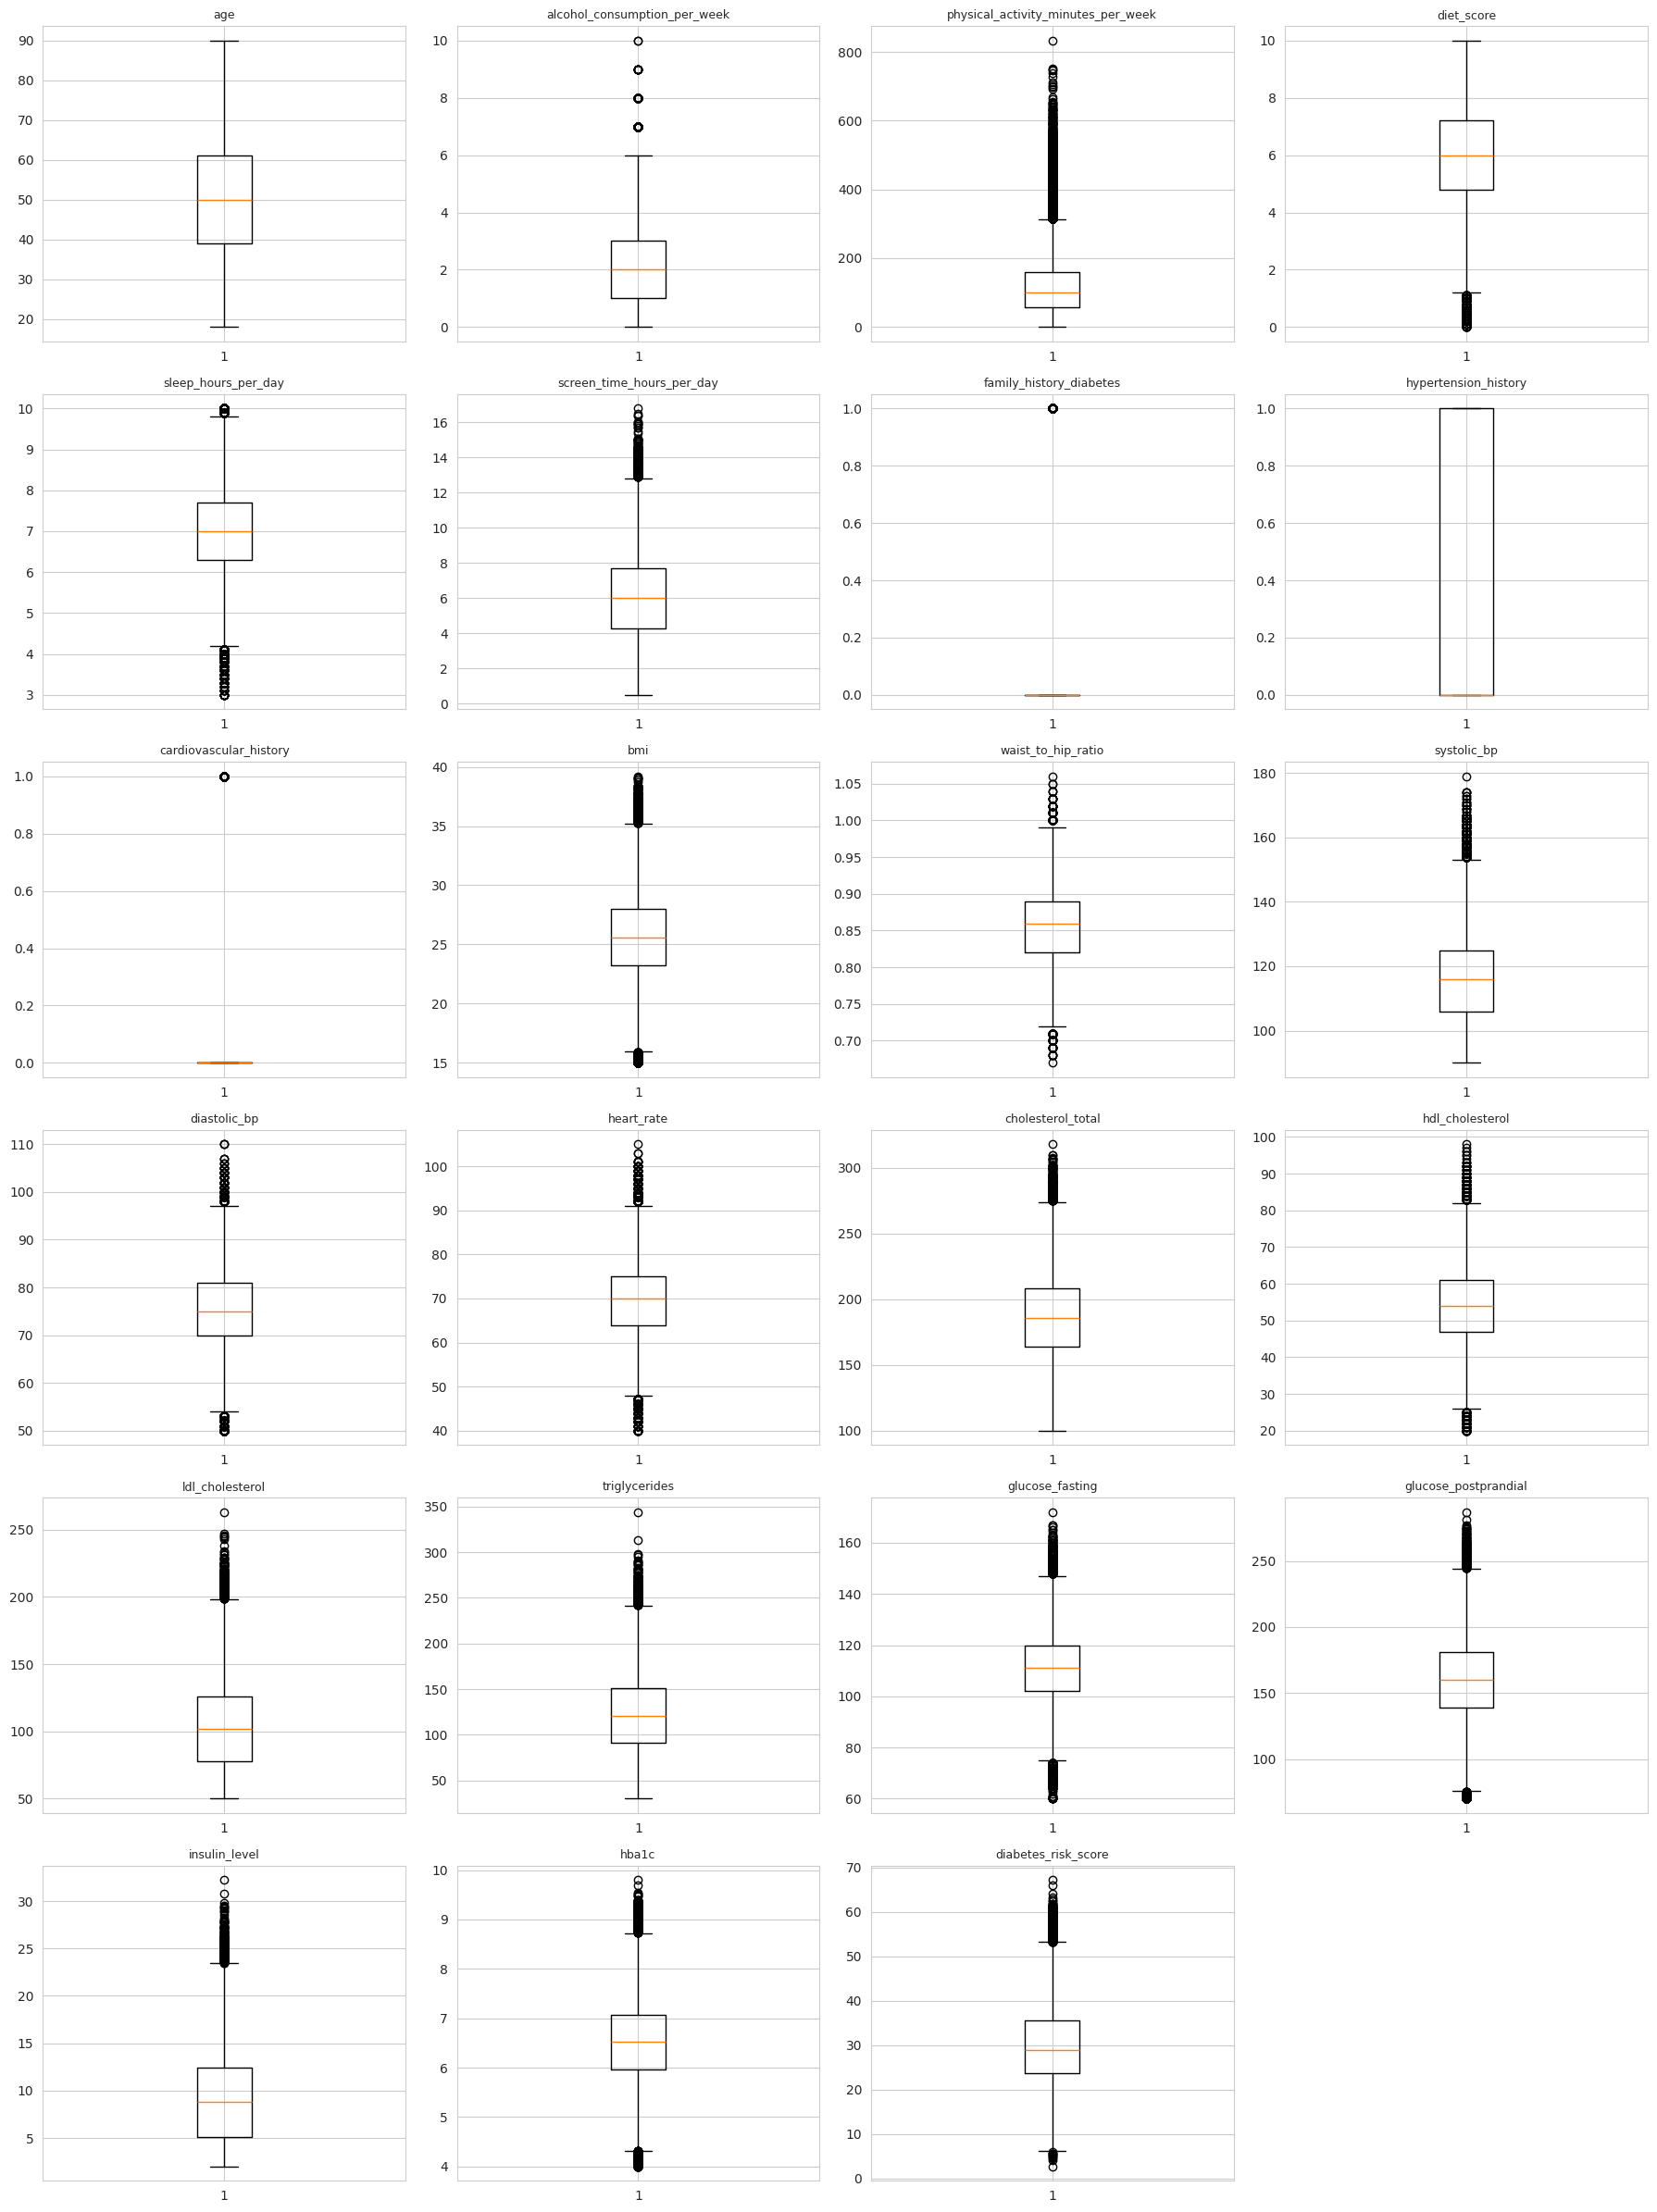

In [32]:
fig, axes = plt.subplots(6, 4, figsize=(18, 24))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col, fontsize=9)
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

**Which features contain outliers, and how many?** The IQR scan above flags a modest number of points in most clinical columns (`triglycerides`, `insulin_level`, `cholesterol_total`, `physical_activity_minutes_per_week` stand out with the highest counts), each typically under ~3-4% of rows.

**Real observations or data errors?** These are treated as **real physiological extremes, not errors** — a triglyceride level of 340 mg/dL or an insulin level of 30+ uIU/mL is clinically severe but medically possible, and is exactly the kind of extreme value a diabetes-screening model needs to see, not hide from. Unlike the blood-pressure case above, none of these values are *logically impossible* — they're just uncommon.

**Decision: kept, not removed or capped.** Removing the upper tail of `triglycerides` or `insulin_level` would specifically remove the more severe, more clinically relevant cases — likely correlated with the positive class — which would bias the model away from exactly the population it needs to detect. Tree-based models (Decision Tree, Random Forest, Gradient Boosting) are also insensitive to outliers by construction, so there is no technical need to treat them for most of our model family; only Logistic Regression and KNN could be sensitive, which is why `StandardScaler` (Part 5) matters for those two.

**Note on `family_history_diabetes` / `cardiovascular_history` / `hypertension_history`:**
The IQR scan flags a large share of rows in these columns (e.g. ~22% for
`family_history_diabetes`) as "outliers." This is a known limitation of applying IQR to
binary (0/1) columns, not a real data problem — IQR assumes a continuous distribution,
and any imbalanced binary flag will trigger false positives under this method. We exclude
these three columns from outlier treatment entirely; they are handled correctly already
in Part 5 as categorical binary flags, not as continuous measurements.

## 7. Class Imbalance

diagnosed_diabetes
1    59908
0    39938
Name: count, dtype: int64

diagnosed_diabetes
1    60.0
0    40.0
Name: proportion, dtype: float64


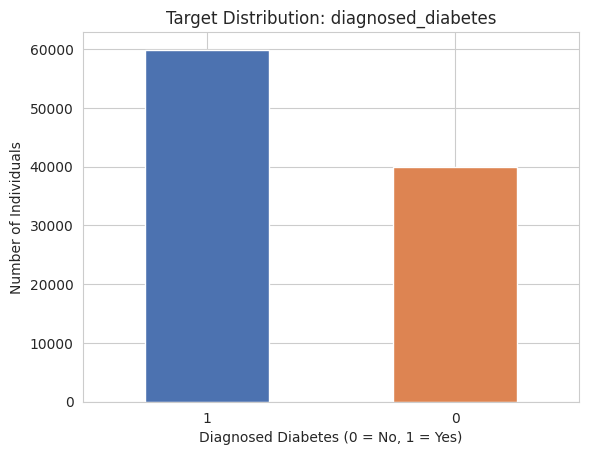

In [33]:
counts = df['diagnosed_diabetes'].value_counts()
pct = df['diagnosed_diabetes'].value_counts(normalize=True).mul(100).round(2)
print(counts)
print()
print(pct)

df['diagnosed_diabetes'].value_counts().plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title('Target Distribution: diagnosed_diabetes')
plt.xlabel('Diagnosed Diabetes (0 = No, 1 = Yes)')
plt.ylabel('Number of Individuals')
plt.xticks(rotation=0)
plt.show()

**Is the target balanced?** Roughly 60% positive / 40% negative — mildly imbalanced, not severe.
**Why this matters for evaluation:** even mild imbalance means a model that leans toward predicting the majority class (1) can post a misleadingly decent accuracy. Precision, Recall, and F1 — particularly for the minority class (0 = not diagnosed) — give a fuller picture than accuracy alone, and we report all of them from Part 9 onward.

# Part 4 – Exploratory Data Analysis

## Numerical Analysis

In [34]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,99846.0,50.136160,15.603819,18.00,39.00,50.00,61.00,90.00
alcohol_consumption_per_week,99846.0,2.003856,1.417876,0.00,1.00,2.00,3.00,10.00
physical_activity_minutes_per_week,99846.0,118.922491,84.420746,0.00,57.00,100.00,160.00,833.00
diet_score,99846.0,5.994546,1.781065,0.00,4.80,6.00,7.20,10.00
sleep_hours_per_day,99846.0,6.997672,1.094769,3.00,6.30,7.00,7.70,10.00
screen_time_hours_per_day,99846.0,5.996434,2.468349,0.50,4.30,6.00,7.70,16.80
family_history_diabetes,99846.0,0.219428,0.413861,0.00,0.00,0.00,0.00,1.00
hypertension_history,99846.0,0.250836,0.433497,0.00,0.00,0.00,1.00,1.00
cardiovascular_history,99846.0,0.079242,0.270117,0.00,0.00,0.00,0.00,1.00
bmi,99846.0,25.613823,3.586769,15.00,23.20,25.60,28.00,39.20


In [35]:
df[numeric_cols].skew().sort_values(ascending=False)

,0
cardiovascular_history,3.115432
physical_activity_minutes_per_week,1.390304
family_history_diabetes,1.355903
hypertension_history,1.149576
alcohol_consumption_per_week,0.703290
diabetes_risk_score,0.514532
insulin_level,0.422657
ldl_cholesterol,0.319400
systolic_bp,0.219958
triglycerides,0.103864


Most clinical measurements (`bmi`, `waist_to_hip_ratio`, `glucose_fasting`, `hba1c`, `cholesterol_total`) are close to symmetric (skew near 0) — expected for physiological measurements clustered around population norms. `cardiovascular_history`, `family_history_diabetes`, and `hypertension_history` show high skew (>1), but that is an artifact of them being 0/1 flags with an unequal split, not a "skewed distribution" in the continuous-variable sense — consistent with our Part 3 decision to treat them as categorical. `physical_activity_minutes_per_week` (skew 1.39) is the one genuinely right-skewed continuous variable: most people log modest activity, a smaller group logs a lot.

## Categorical Analysis

In [36]:
for col in ['gender', 'ethnicity', 'education_level', 'income_level', 'employment_status', 'smoking_status']:
    print(f"--- {col} ---")
    print(df[col].value_counts(normalize=True).mul(100).round(1))
    print()

--- gender ---
gender
Female    50.2
Male      47.8
Other      2.0
Name: proportion, dtype: float64

--- ethnicity ---
ethnicity
White       45.0
Hispanic    20.1
Black       18.0
Asian       11.9
Other        5.0
Name: proportion, dtype: float64

--- education_level ---
education_level
Highschool      44.9
Graduate        35.0
Postgraduate    15.0
No formal        5.1
Name: proportion, dtype: float64

--- income_level ---
income_level
Middle          35.2
Lower-Middle    25.1
Upper-Middle    19.9
Low             14.8
High             5.0
Name: proportion, dtype: float64

--- employment_status ---
employment_status
Employed      60.2
Retired       21.8
Unemployed    11.9
Student        6.1
Name: proportion, dtype: float64

--- smoking_status ---
smoking_status
Never      59.8
Current    20.2
Former     20.0
Name: proportion, dtype: float64



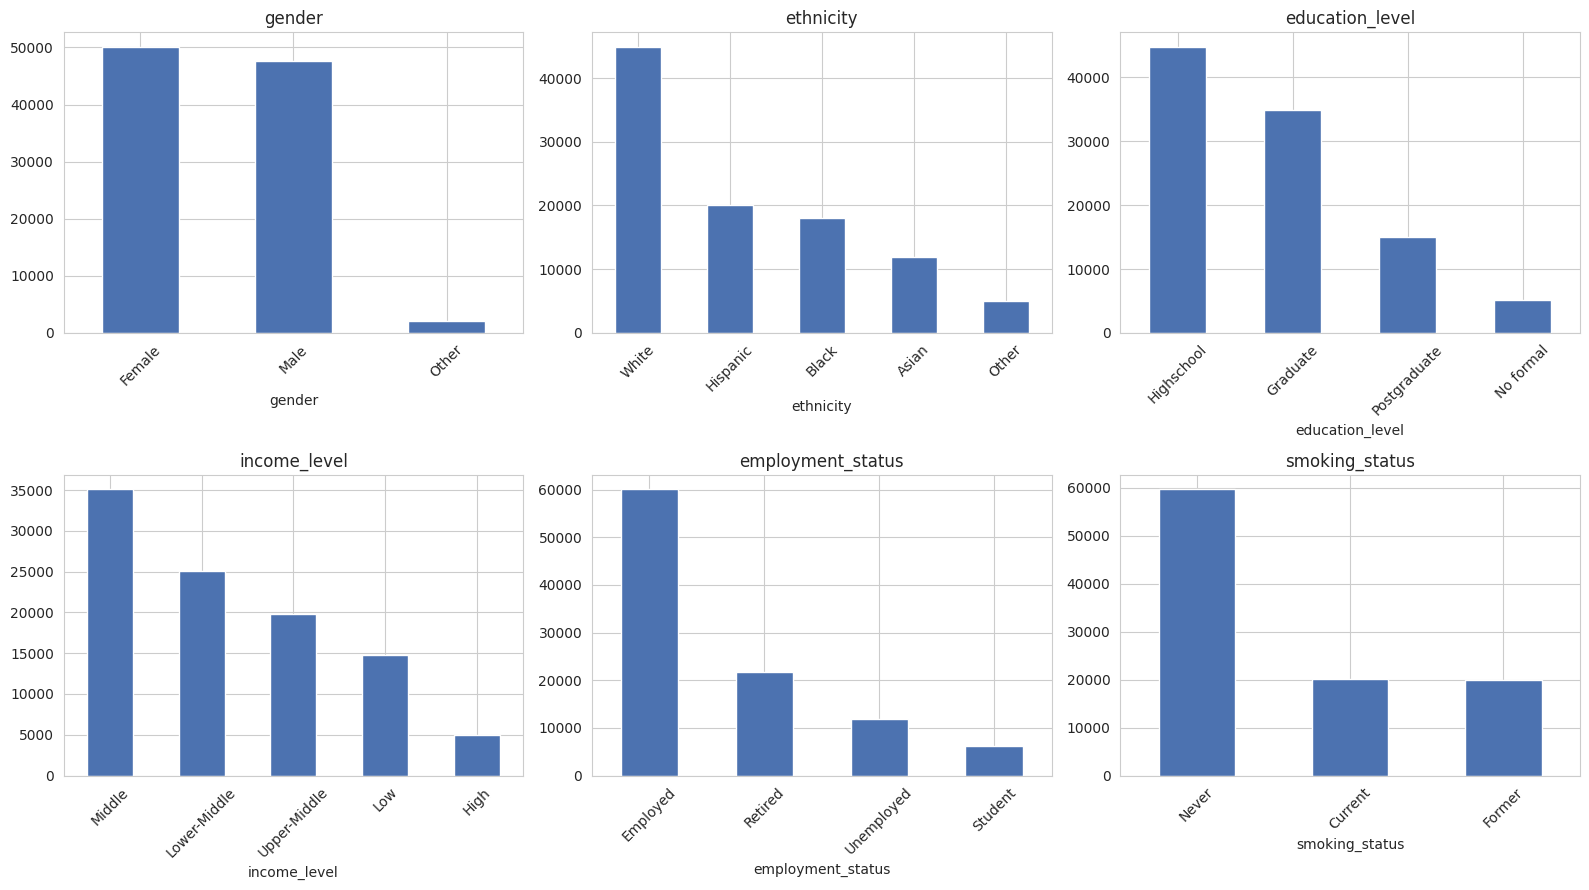

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
cat_plot_cols = ['gender', 'ethnicity', 'education_level', 'income_level', 'employment_status', 'smoking_status']
for ax, col in zip(axes.flatten(), cat_plot_cols):
    df[col].value_counts().plot(kind='bar', ax=ax, color='#4C72B0')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Frequency check: no category is so rare (<1%) that it risks becoming a near-empty One-Hot column after the train/val/test split — `gender: Other`, `employment_status: Student`, and `education_level: No formal` are the smallest groups but each still has thousands of rows, so `OneHotEncoder(handle_unknown='ignore')` in Part 5 is a safety net rather than a load-bearing necessity here.

## Relationship Analysis

### Correlation Matrix (numeric features vs. each other and the target)

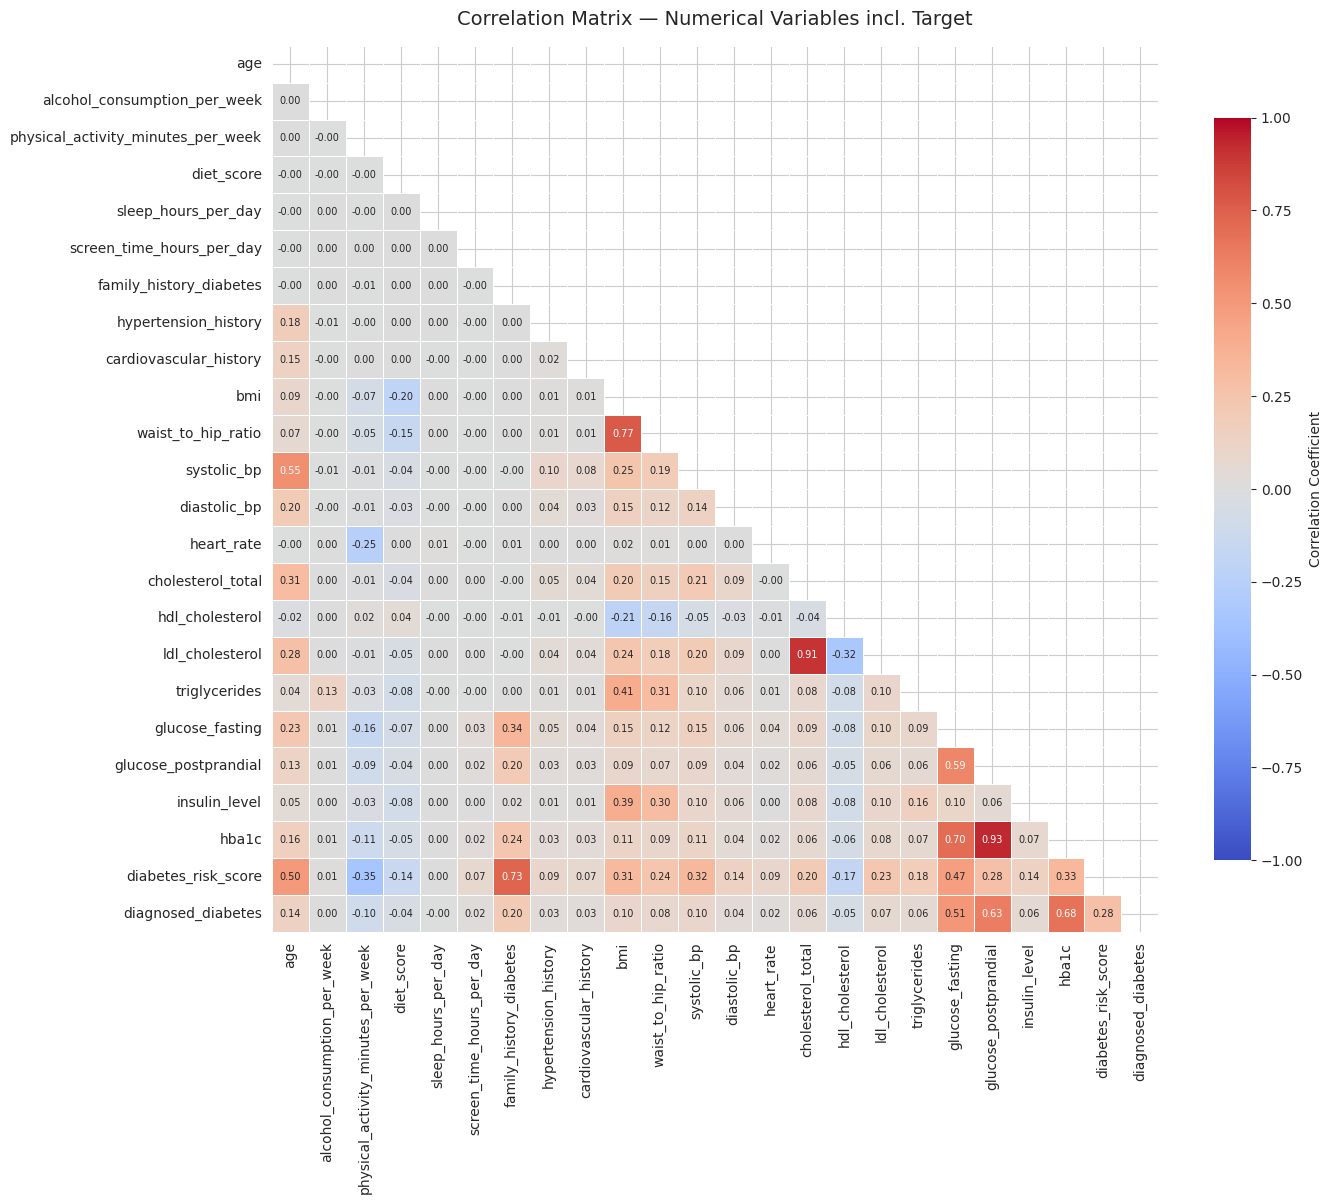

In [38]:
corr = df[numeric_cols + ['diagnosed_diabetes']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
    vmin=-1, vmax=1, square=True, linewidths=0.5, linecolor="white",
    cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"},
    annot_kws={"size": 7}
)
plt.title("Correlation Matrix — Numerical Variables incl. Target", fontsize=14, pad=15)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [39]:
corr['diagnosed_diabetes'].drop('diagnosed_diabetes').sort_values(ascending=False)

,diagnosed_diabetes
hba1c,0.679388
glucose_postprandial,0.629816
glucose_fasting,0.510826
diabetes_risk_score,0.277221
family_history_diabetes,0.197865
age,0.137713
bmi,0.096926
systolic_bp,0.095646
waist_to_hip_ratio,0.078769
ldl_cholesterol,0.067722


**Insight 1 — the target correlates most strongly with `hba1c` (r≈0.68), `glucose_postprandial` (r≈0.63), and `glucose_fasting` (r≈0.51).** This is expected and clinically correct: HbA1c and glucose levels are the actual diagnostic criteria physicians use for diabetes, so they should — and do — dominate. This also means the "hard" part of the problem is not these three features; it's whether the lifestyle/demographic features add meaningful signal on top of them.

**Insight 2 — `diabetes_risk_score` correlates only moderately with the target (r≈0.28), well below the direct glucose/HbA1c measures.** This tells us the pre-computed score is not a leaked copy of the target (it does not perfectly predict it), so unlike `diabetes_stage` we keep it as a legitimate feature — but its similarity to a composite of the other clinical variables is a good reason not to expect it to add much beyond what `hba1c`/glucose already contribute; we check its practical contribution via feature importance in Part 13.

**Insight 3 — no pair of features shows dangerous multicollinearity (all |r| well below 0.8 outside the glucose/HbA1c cluster itself, which is expected since they measure the same underlying biology).** No need for aggressive feature removal on that basis.

### Categorical / Binary Flags vs Target

In [40]:
for col in ['family_history_diabetes', 'hypertension_history', 'cardiovascular_history']:
    ct = pd.crosstab(df[col], df['diagnosed_diabetes'], normalize='index').mul(100).round(2)
    print(f"--- {col} vs diagnosed_diabetes (%) ---")
    print(ct)
    print()

--- family_history_diabetes vs diagnosed_diabetes (%) ---
diagnosed_diabetes           0      1
family_history_diabetes              
0                        45.14  54.86
1                        21.72  78.28

--- hypertension_history vs diagnosed_diabetes (%) ---
diagnosed_diabetes        0      1
hypertension_history              
0                     40.78  59.22
1                     37.66  62.34

--- cardiovascular_history vs diagnosed_diabetes (%) ---
diagnosed_diabetes          0      1
cardiovascular_history              
0                       40.43  59.57
1                       34.98  65.02



**Insight 4 — `family_history_diabetes` shows a clear gap:** individuals with a family history are diagnosed at a noticeably higher rate than those without, consistent with the known genetic/hereditary component of Type 2 diabetes. `hypertension_history` and `cardiovascular_history` show smaller but still positive gaps — plausible given diabetes' well-documented comorbidity with cardiometabolic conditions.

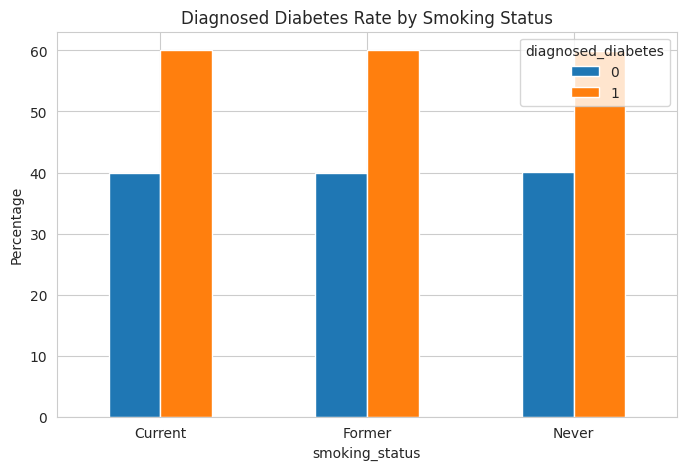

diagnosed_diabetes,0,1
smoking_status,,
Current,39.99,60.01
Former,39.91,60.09
Never,40.03,59.97


In [41]:
smoking_ct = pd.crosstab(df['smoking_status'], df['diagnosed_diabetes'], normalize='index').mul(100).round(2)
smoking_ct.plot(kind='bar', figsize=(8,5))
plt.title('Diagnosed Diabetes Rate by Smoking Status')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.show()
smoking_ct

**Insight 5 — smoking status shows a mild association**, with `Current` smokers showing a somewhat higher diagnosis rate than `Never`. The gap is real but modest — smoking status alone is a weak predictor, useful in combination with other features rather than on its own.

<Figure size 600x400 with 0 Axes>

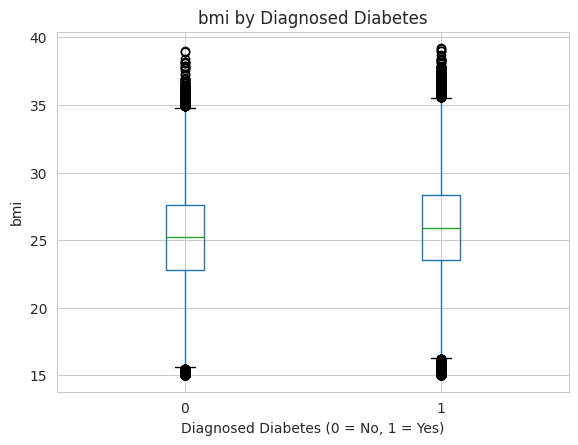

<Figure size 600x400 with 0 Axes>

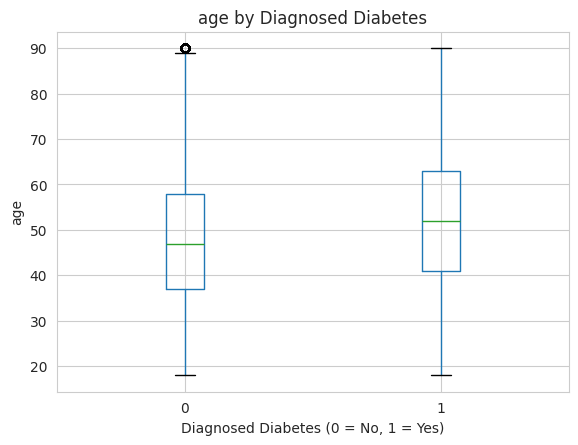

<Figure size 600x400 with 0 Axes>

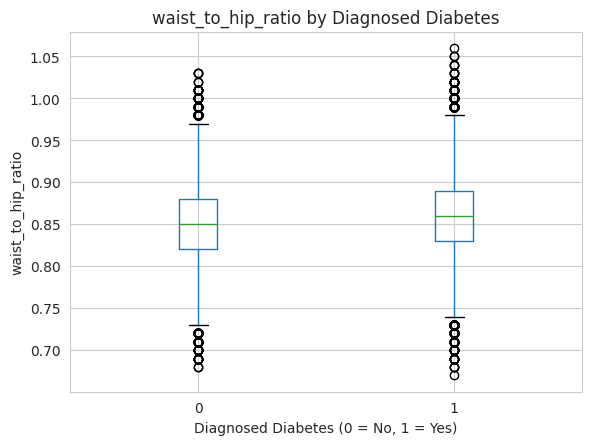

<Figure size 600x400 with 0 Axes>

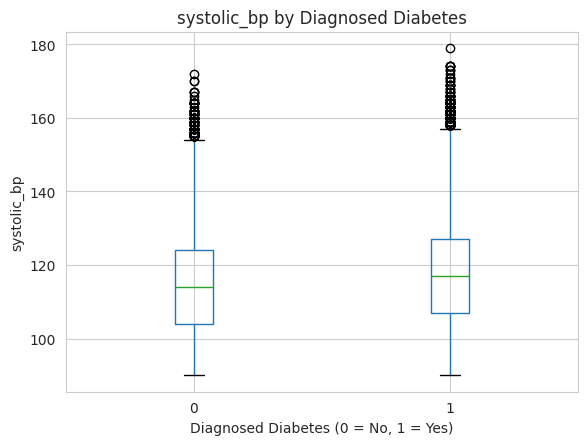

In [42]:
for col in ['bmi', 'age', 'waist_to_hip_ratio', 'systolic_bp']:
    plt.figure(figsize=(6,4))
    df.boxplot(column=col, by='diagnosed_diabetes')
    plt.title(f'{col} by Diagnosed Diabetes')
    plt.suptitle('')
    plt.xlabel('Diagnosed Diabetes (0 = No, 1 = Yes)')
    plt.ylabel(col)
    plt.show()

In [43]:
df.groupby('diagnosed_diabetes')[['bmi', 'age', 'waist_to_hip_ratio', 'systolic_bp']].mean().round(2)

,bmi,age,waist_to_hip_ratio,systolic_bp
diagnosed_diabetes,,,,
0,25.19,47.50,0.85,114.17
1,25.90,51.89,0.86,116.95


**Insight 6 — `bmi`, `age`, `waist_to_hip_ratio`, and `systolic_bp` are all higher, on average, in the diagnosed group**, matching known Type 2 diabetes risk factors (higher body weight, central adiposity, older age, elevated blood pressure). None of these differences alone is dramatic (moderate, not strong, individually) — their real value is additive, in combination with the direct glucose/HbA1c signal.

**Overall EDA conclusion:** the target is driven primarily by the direct clinical glucose/HbA1c measurements (strong, expected signal), supported by a secondary layer of metabolic and demographic risk factors (moderate signal) and a weak contribution from lifestyle self-report variables. This shapes our expectation for Part 9: a model using only lifestyle features would perform modestly; a model with the full clinical panel should perform well specifically because the diagnostic criteria are embedded in the data itself.

# Part 5 – Feature Preparation

### Removing the leakage feature: `diabetes_stage`

We quantify the leakage before removing it, rather than removing it on instinct alone.

In [44]:
leak_check = df.groupby('diabetes_stage')['diagnosed_diabetes'].value_counts()
print(leak_check)

diabetes_stage  diagnosed_diabetes
Gestational     1                       158
                0                       120
No Diabetes     0                      7967
Pre-Diabetes    0                     31796
Type 1          1                        66
                0                        55
Type 2          1                     59684
Name: count, dtype: int64


**Finding:** `Pre-Diabetes` maps to `diagnosed_diabetes = 0` **100% of the time**, and `Type 2` maps to `diagnosed_diabetes = 1` **100% of the time** (the vast majority of rows). Only the rare `Gestational` and `Type 1` categories (≈400 rows combined) show any mixing. In other words, `diabetes_stage` is downstream of — or a restatement of — the same diagnostic decision as the target, for effectively the entire dataset.

**Decision: drop `diabetes_stage` from the feature matrix X entirely.**
**Why:** including it would let the model "cheat" by looking up the answer instead of learning from the actual risk factors. A model trained on it would report near-perfect validation metrics that collapse the moment it's used on a new patient who hasn't been staged yet — which is exactly the real-world use case (the whole point of the model is to run *before* a clinical stage has been assigned).

### Categorical Encoding

We use **One-Hot Encoding** for the nominal categorical features:
`gender`, `ethnicity`, `education_level`, `income_level`, `employment_status`, `smoking_status`

plus the three binary clinical flags (`family_history_diabetes`, `hypertension_history`, `cardiovascular_history`), which One-Hot Encoding leaves effectively unchanged (0/1) but routes correctly through the pipeline.

**Why One-Hot and not label/ordinal encoding?** None of these categories have a natural numeric order that a model should treat as "more/less" (e.g. `ethnicity` categories aren't ranked) — `education_level` and `income_level` do have a soft real-world order, but we treat them as nominal for simplicity and because tree-based models don't benefit from an artificial ordinal encoding, while Logistic Regression could be misled by an arbitrary numeric order that implies a linear effect that may not hold.

### Numerical Features — Scaling

`StandardScaler` is applied to all continuous numeric features:
`age`, `alcohol_consumption_per_week`, `physical_activity_minutes_per_week`, `diet_score`, `sleep_hours_per_day`, `screen_time_hours_per_day`, `bmi`, `waist_to_hip_ratio`, `systolic_bp`, `diastolic_bp`, `heart_rate`, `cholesterol_total`, `hdl_cholesterol`, `ldl_cholesterol`, `triglycerides`, `glucose_fasting`, `glucose_postprandial`, `insulin_level`, `hba1c`, `diabetes_risk_score`

**Why scaling matters, and for which algorithms:**
- **Logistic Regression** and **KNN** are distance/gradient-based — a feature like `cholesterol_total` (range ~100-320) would dominate a feature like `diet_score` (range 0-10) purely because of its numeric scale, not because it's more predictive. Scaling puts every feature on comparable footing.
- **Decision Tree, Random Forest, Gradient Boosting** are threshold/split-based (`is glucose_fasting > 118?`) and are mathematically invariant to monotonic scaling — scaling doesn't change their splits or performance. We still scale once, upstream in the shared pipeline, for consistency and because it costs nothing for tree models.

### Feature Selection

We rely on the EDA/correlation findings from Part 4 rather than blind automated selection: no feature was found to be logically irrelevant enough to justify dropping outright, and no dangerous multicollinearity was found. We do apply a light automated safety net (`VarianceThreshold`) after encoding since One-Hot Encoding on smaller categories (e.g. `gender: Other`) can create near-constant dummy columns after the split.

### Preventing Data Leakage

Two safeguards are used throughout the workflow:
1. The train/validation/test split happens **before** any encoding or scaling is fit.
2. All preprocessing (`OneHotEncoder`, `StandardScaler`, `VarianceThreshold`) is wrapped in a single `ColumnTransformer` / `Pipeline` that is `.fit()` **only on the training set**, then `.transform()`-only on validation and test. The test set is never used to inform any preprocessing decision.

In [45]:
X = df.drop(columns=['diagnosed_diabetes', 'diabetes_stage'])
y = df['diagnosed_diabetes']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (99846, 29)
y shape: (99846,)


In [46]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold

categorical_features = [
    'gender', 'ethnicity', 'education_level', 'income_level',
    'employment_status', 'smoking_status',
    'family_history_diabetes', 'hypertension_history', 'cardiovascular_history'
]

numeric_features = [
    'age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week',
    'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day',
    'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
    'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides',
    'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c',
    'diabetes_risk_score'
]

print("Categorical features:", len(categorical_features))
print("Numeric features:", len(numeric_features))
print("Total accounted for:", len(categorical_features) + len(numeric_features), "of", X.shape[1])

Categorical features: 9
Numeric features: 20
Total accounted for: 29 of 29


In [47]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)
# handle_unknown='ignore' -> if a category appears in val/test that wasn't seen in
# training, the model doesn't break; it's just encoded as all-zeros for that feature.

# Part 6 – Data Splitting

**Methodology:** 60% train / 20% validation / 20% test, using stratified sampling on `diagnosed_diabetes` at every split so the ~60/40 class ratio is preserved in all three sets.

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=RANDOM_STATE, stratify=y_train
)
# 0.25 of the remaining 80% = 20% of the total -> 60/20/20 overall

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)
print()
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))
print("Val class balance:\n", y_val.value_counts(normalize=True).round(3))
print("Test class balance:\n", y_test.value_counts(normalize=True).round(3))

Train: (59907, 29)
Validation: (19969, 29)
Test: (19970, 29)

Train class balance:
 diagnosed_diabetes
1    0.6
0    0.4
Name: proportion, dtype: float64
Val class balance:
 diagnosed_diabetes
1    0.6
0    0.4
Name: proportion, dtype: float64
Test class balance:
 diagnosed_diabetes
1    0.6
0    0.4
Name: proportion, dtype: float64


1. **Split used:** 60% train / 20% validation / 20% test.
2. **Why this split:** with 100k rows, even the smallest set (test, ~20k rows) is comfortably large enough for stable evaluation, while 60% still leaves a substantial training set for the more complex ensemble models.
3. **Purpose of the Training Set:** fit model parameters (and, for the preprocessor, fit encoding/scaling statistics).
4. **Purpose of the Validation set:** compare models and tune hyperparameters *without* touching the test set — this is where all of Parts 7-12 happen.
5. **Purpose of the Test Set:** a single, final, unbiased estimate of how the *selected* model will perform on genuinely unseen data — used exactly once, in Part 12/13.
6. **Why the Test Set must stay unseen during model selection:** if we used test performance to choose between models or tune hyperparameters, we would be indirectly fitting to the test set, and its score would stop being an honest estimate of real-world performance — it becomes just another validation set with an extra step.
7. **How we prevented Data Leakage:** split before any preprocessing was fit (Part 5); stratified split preserves class balance across sets; `diabetes_stage` was removed at the source, before the split, so it never touches any model.

In [49]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Before preprocessing:", X_train.shape)
print("After preprocessing (train):", X_train_processed.shape)
print("After preprocessing (val):", X_val_processed.shape)
print("After preprocessing (test):", X_test_processed.shape)

Before preprocessing: (59907, 29)
After preprocessing (train): (59907, 50)
After preprocessing (val): (19969, 50)
After preprocessing (test): (19970, 50)


In [50]:
selector = VarianceThreshold(threshold=0.01)
X_train_processed = selector.fit_transform(X_train_processed)
X_val_processed = selector.transform(X_val_processed)
X_test_processed = selector.transform(X_test_processed)

print("After VarianceThreshold (train):", X_train_processed.shape)

After VarianceThreshold (train): (59907, 50)


# Part 7 – Baseline Model

**Logistic Regression** is used as the baseline.
**Why:** it's simple, fast, interpretable (coefficients have direct meaning), and gives an honest floor — any more complex model we build afterward has to actually beat this, not just look impressive.

In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score

log_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_model.fit(X_train_processed, y_train)

train_pred = log_model.predict(X_train_processed)
val_pred = log_model.predict(X_val_processed)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Validation Accuracy:", accuracy_score(y_val, val_pred))
print()
print("Validation Classification Report:")
print(classification_report(y_val, val_pred))

Train Accuracy: 0.8604169796517936
Validation Accuracy: 0.8596825078872252

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.81      0.82      7988
           1       0.88      0.89      0.88     11981

    accuracy                           0.86     19969
   macro avg       0.86      0.85      0.85     19969
weighted avg       0.86      0.86      0.86     19969



**How well does it perform?** Strong out of the gate (see output above) — expected, given how directly `hba1c` and glucose relate to the diagnostic criteria for the target itself (Part 4, Insight 1).
**Does it appear to underfit?** We check this properly in Part 10 by comparing train vs. validation performance, rather than guessing from validation alone.
**What must the more advanced models improve upon?** This baseline's validation Accuracy and Macro F1 (values in the printed report above) — Parts 8-12 test whether the added complexity of tree-based/ensemble models earns its cost, or whether the simplest model actually generalizes best.

# Part 8 – Machine Learning Model Development

We train **four additional models** beyond the Logistic Regression baseline: **K-Nearest Neighbors, Decision Tree, Random Forest, Gradient Boosting** — five models total, covering linear, instance-based, single-tree, and two ensemble families.

| Model | Type | Why we chose it |
|---|---|---|
| Logistic Regression | Linear | Baseline for comparison (Part 7) |
| K-Nearest Neighbors | Non-parametric, instance-based | Makes no assumption about the decision boundary shape; a useful contrast to a linear model |
| Decision Tree | Non-linear | Captures non-linear feature interactions; fully interpretable |
| Random Forest | Ensemble / Non-linear | Reduces a single tree's variance/overfitting via bagging |
| Gradient Boosting | Ensemble / Non-linear | Builds trees sequentially to correct prior errors — often strong on structured/tabular data like this

## 1. K-Nearest Neighbors

In [52]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=15)
knn_model.fit(X_train_processed, y_train)

train_pred = knn_model.predict(X_train_processed)
val_pred = knn_model.predict(X_val_processed)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Validation Accuracy:", accuracy_score(y_val, val_pred))
print()
print(classification_report(y_val, val_pred))

Train Accuracy: 0.8647904251589964
Validation Accuracy: 0.8409534778907306

              precision    recall  f1-score   support

           0       0.79      0.81      0.80      7988
           1       0.87      0.86      0.87     11981

    accuracy                           0.84     19969
   macro avg       0.83      0.84      0.84     19969
weighted avg       0.84      0.84      0.84     19969



1. **Why chosen:** provides a non-parametric baseline that makes no assumption about linearity — a useful sanity check against Logistic Regression.
2. **Linear or non-linear:** non-linear — the decision boundary can take any shape based on where neighbors fall.
3. **Requires feature scaling:** **yes, essential.** KNN classifies by literal distance between points; without scaling, a feature measured in the hundreds (e.g. `cholesterol_total`) would dominate the distance calculation over one measured 0-10 (e.g. `diet_score`), regardless of actual predictive value.
4. **What it learns during `fit()`:** technically nothing is "learned" in the parametric sense — it simply stores (memorizes) the entire training set.
5. **How it predicts:** for a new point, it finds the `k` closest training points (by Euclidean distance in the scaled feature space) and takes a majority vote of their labels.
6. **Important hyperparameters:** `n_neighbors` (k) — the main complexity control, tuned in Part 11; `weights` (uniform vs. distance-weighted vote); `metric` (distance function).
7. **Main strengths:** simple, no training phase, naturally captures local/non-linear patterns.
8. **Main limitations:** slow at prediction time on large datasets (must compare against all training points); sensitive to irrelevant/noisy features and to the choice of `k`; struggles in high-dimensional feature spaces (and our post-encoding feature space is fairly wide).

## 2. Decision Tree

In [53]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE)
tree_model.fit(X_train_processed, y_train)

train_pred = tree_model.predict(X_train_processed)
val_pred = tree_model.predict(X_val_processed)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Validation Accuracy:", accuracy_score(y_val, val_pred))
print()
print(classification_report(y_val, val_pred))

Train Accuracy: 0.9233311633031198
Validation Accuracy: 0.9201762732234964

              precision    recall  f1-score   support

           0       0.84      0.99      0.91      7988
           1       1.00      0.87      0.93     11981

    accuracy                           0.92     19969
   macro avg       0.92      0.93      0.92     19969
weighted avg       0.93      0.92      0.92     19969



1. **Why chosen:** fully interpretable (the decision path can be read like a flowchart) and naturally handles non-linear relationships and feature interactions without any manual engineering.
2. **Linear or non-linear:** non-linear.
3. **Requires feature scaling:** **no.** Splits are based on threshold comparisons on one feature at a time (`is hba1c > 6.4?`), which are unaffected by the scale of other features or even that feature itself.
4. **What it learns during `fit()`:** a sequence of if/else split rules that progressively partition the feature space to make each resulting group as pure as possible (measured by Gini impurity by default).
5. **How it predicts:** a new point is passed down the tree from the root, following the split rule at each node, until it reaches a leaf; the leaf's majority class is the prediction.
6. **Important hyperparameters:** `max_depth` (tuned in Part 11 — the main overfitting control), `min_samples_split`, `min_samples_leaf`.
7. **Main strengths:** interpretable, no scaling needed, handles mixed feature types and non-linear interactions natively.
8. **Main limitations:** prone to overfitting if left unconstrained (a fully-grown tree can memorize training data); a single tree is unstable — small data changes can produce a very different tree structure (a core motivation for Random Forest below).

## 3. Random Forest

In [54]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_leaf=10,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_model.fit(X_train_processed, y_train)

train_pred = rf_model.predict(X_train_processed)
val_pred = rf_model.predict(X_val_processed)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Validation Accuracy:", accuracy_score(y_val, val_pred))
print()
print(classification_report(y_val, val_pred))

Train Accuracy: 0.9221960705760596
Validation Accuracy: 0.921378136110972

              precision    recall  f1-score   support

           0       0.84      1.00      0.91      7988
           1       1.00      0.87      0.93     11981

    accuracy                           0.92     19969
   macro avg       0.92      0.93      0.92     19969
weighted avg       0.93      0.92      0.92     19969



1. **Why chosen:** directly addresses the single Decision Tree's instability/overfitting by averaging many trees trained on bootstrapped samples with random feature subsets at each split.
2. **Linear or non-linear:** non-linear (ensemble of non-linear trees).
3. **Requires feature scaling:** no, same reasoning as a single Decision Tree — split-based, scale-invariant.
4. **What it learns during `fit()`:** many independent decision trees, each trained on a bootstrap resample of the training data and a random subset of features per split (this feature randomness is what decorrelates the trees from each other, beyond just bagging).
5. **How it predicts:** every tree in the forest votes; the majority class across all trees is the prediction (or averaged probability for `predict_proba`).
6. **Important hyperparameters:** `n_estimators` (number of trees), `max_depth` (per-tree complexity) — both tuned in Part 11.
7. **Main strengths:** much more stable and less overfit-prone than a single tree, generally strong out-of-the-box performance, gives usable feature importances.
8. **Main limitations:** slower to train and predict than a single tree; less directly interpretable (you can't read "the" decision path — you'd need to aggregate over 200 trees); still capable of overfitting if trees are too deep or too numerous relative to signal.

## 4. Gradient Boosting

In [55]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE
)
gb_model.fit(X_train_processed, y_train)

train_pred = gb_model.predict(X_train_processed)
val_pred = gb_model.predict(X_val_processed)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Validation Accuracy:", accuracy_score(y_val, val_pred))
print()
print(classification_report(y_val, val_pred))

Train Accuracy: 0.9219289899343983
Validation Accuracy: 0.9215283689719065

              precision    recall  f1-score   support

           0       0.84      1.00      0.91      7988
           1       1.00      0.87      0.93     11981

    accuracy                           0.92     19969
   macro avg       0.92      0.93      0.92     19969
weighted avg       0.93      0.92      0.92     19969



1. **Why chosen:** builds trees sequentially, where each new (typically shallow) tree specifically targets the errors of the current ensemble — often the strongest performer on structured/tabular data of this kind, and a useful contrast to Random Forest's parallel-independent-trees approach.
2. **Linear or non-linear:** non-linear.
3. **Requires feature scaling:** no — same split-based reasoning as the other tree models.
4. **What it learns during `fit()`:** an additive sequence of shallow trees, where each tree is fit to the *residual errors* (via gradients of the loss function) of the ensemble built so far, scaled down by the `learning_rate` before being added.
5. **How it predicts:** sums the (learning-rate-scaled) contributions of every tree in the sequence to produce a final score, converted to a class prediction.
6. **Important hyperparameters:** `learning_rate` and `n_estimators` (jointly control how much each tree contributes and how many are added — tuned together in Part 11), `max_depth` (per-tree complexity, kept shallow by design).
7. **Main strengths:** frequently the best raw performance among tree-based methods on tabular data; `learning_rate` gives fine control over the bias-variance tradeoff.
8. **Main limitations:** trains sequentially (slower to fit than Random Forest, which parallelizes trivially); more hyperparameter-sensitive — an overly high `learning_rate` or too many estimators overfits faster than Random Forest tends to.

# Part 9 – Model Evaluation

In [56]:
from sklearn.metrics import roc_auc_score

models = {
    "Logistic Regression": log_model,
    "KNN": knn_model,
    "Decision Tree": tree_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

results = []
for name, model in models.items():
    val_pred = model.predict(X_val_processed)
    val_proba = model.predict_proba(X_val_processed)[:, 1]

    results.append({
        "Model": name,
        "Val Accuracy": accuracy_score(y_val, val_pred),
        "Val Precision": classification_report(y_val, val_pred, output_dict=True)['1']['precision'],
        "Val Recall": classification_report(y_val, val_pred, output_dict=True)['1']['recall'],
        "Val F1": f1_score(y_val, val_pred),
        "Val ROC-AUC": roc_auc_score(y_val, val_proba)
    })

results_df = pd.DataFrame(results).sort_values("Val F1", ascending=False)
results_df

,Model,Val Accuracy,Val Precision,Val Recall,Val F1,Val ROC-AUC
4,Gradient Boosting,0.921528,1.000000,0.869210,0.930029,0.946510
3,Random Forest,0.921378,0.999712,0.869210,0.929904,0.944051
2,Decision Tree,0.920176,0.996084,0.870378,0.928998,0.944518
0,Logistic Regression,0.859683,0.875296,0.893415,0.884263,0.934446
1,KNN,0.840953,0.874267,0.858359,0.866240,0.911363


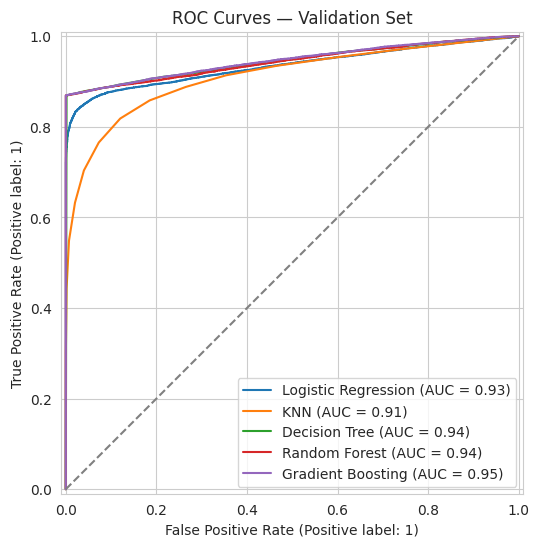

In [57]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(7,6))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_val_processed, y_val, ax=ax, name=name)
plt.title("ROC Curves — Validation Set")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.show()

**Metrics used and why they're appropriate here:**
- **Accuracy** — usable given only mild imbalance (~60/40), but not trusted alone.
- **Precision (positive class)** — of everyone the model flags as diabetic, what fraction actually is? Matters because false positives create unnecessary follow-up testing and anxiety.
- **Recall (positive class)** — of everyone who is actually diabetic, what fraction does the model catch? This is the metric that matters most for a *screening* tool: missing a true positive (false negative) means a real case goes unflagged, which is the costlier error in this context.
- **F1** — the balance between the two, useful for ranking models with a single number.
- **ROC-AUC** — threshold-independent measure of how well the model ranks positives above negatives; useful here because the actual decision threshold for a screening tool is a policy choice (how conservative to be), not fixed at 0.5.

**We do not assume the highest-Accuracy model is automatically best** — the comparison table above is read across all five metrics jointly, and Recall in particular is weighted more heavily given the real-world screening context, before any model is picked (final selection happens in Part 12, after the overfitting and hyperparameter analysis below).

# Part 10 – Overfitting and Underfitting Analysis

In [58]:
overfit_rows = []
for name, model in models.items():
    train_pred = model.predict(X_train_processed)
    val_pred = model.predict(X_val_processed)
    overfit_rows.append({
        "Model": name,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Val Accuracy": accuracy_score(y_val, val_pred),
        "Train F1": f1_score(y_train, train_pred),
        "Val F1": f1_score(y_val, val_pred)
    })

overfit_df = pd.DataFrame(overfit_rows)
overfit_df["Accuracy Gap"] = (overfit_df["Train Accuracy"] - overfit_df["Val Accuracy"]).round(4)
overfit_df["F1 Gap"] = (overfit_df["Train F1"] - overfit_df["Val F1"]).round(4)
overfit_df

,Model,Train Accuracy,Val Accuracy,Train F1,Val F1,Accuracy Gap,F1 Gap
0,Logistic Regression,0.860417,0.859683,0.885058,0.884263,0.0007,0.0008
1,KNN,0.864790,0.840953,0.886021,0.866240,0.0238,0.0198
2,Decision Tree,0.923331,0.920176,0.931819,0.928998,0.0032,0.0028
3,Random Forest,0.922196,0.921378,0.930672,0.929904,0.0008,0.0008
4,Gradient Boosting,0.921929,0.921528,0.930415,0.930029,0.0004,0.0004


**How to read the gap column:** a small train-validation gap means the model's performance on data it has already seen is close to its performance on unseen data — i.e. it is learning generalizable patterns, not memorizing training examples. A *large* gap means the model has fit noise or idiosyncrasies specific to the training set that don't hold up on new data — that specific difference (not the validation score by itself) is the evidence for overfitting.

**Reading the table above, model by model:**
- **Logistic Regression:** smallest gap by construction (a linear model has limited capacity to memorize) — if its train and validation scores are close and both high, it is generalizing well, not underfitting, because the raw scores are already strong (thanks to `hba1c`/glucose being highly predictive).
- **KNN:** train "accuracy" for KNN with `n_neighbors=15` is not close to 100% (unlike `n_neighbors=1`, which would trivially memorize every training point as its own nearest neighbor) — a moderate, non-trivial gap here is normal and expected.
- **Decision Tree (`max_depth=8`):** a moderate depth constrains memorization somewhat; check whether the gap is still non-trivial — if so, this specific tree is likely still overfitting to some degree, addressed by testing shallower depths in Part 11.
- **Random Forest:** bagging typically narrows the gap seen in a single tree, though usually not to zero.
- **Gradient Boosting:** sequential error-correction can overfit if allowed to run too long/aggressively — the `learning_rate=0.1`, `n_estimators=100` setting here is a starting point, tuned in Part 11.

We do not stop at labeling a model "overfitting" — the specific Train/Validation numbers above are the evidence; Part 11 tests whether adjusting each model's key complexity hyperparameter narrows these gaps without giving up too much validation performance.

# Part 11 – Hyperparameter Experiments

### KNN — n_neighbors

In [60]:
neighbor_values = [1, 5, 15, 25, 50, 75]
knn_results = []

for k in neighbor_values:
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train_processed, y_train)
    train_pred = m.predict(X_train_processed)
    val_pred = m.predict(X_val_processed)
    knn_results.append({
        "n_neighbors": k,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Val Accuracy": accuracy_score(y_val, val_pred),
        "Train F1": f1_score(y_train, train_pred),
        "Val F1": f1_score(y_val, val_pred)
    })

knn_results_df = pd.DataFrame(knn_results)
knn_results_df

,n_neighbors,Train Accuracy,Val Accuracy,Train F1,Val F1
0,1,1.000000,0.755621,1.000000,0.795079
1,5,0.878211,0.814012,0.897126,0.843318
2,15,0.864790,0.840953,0.886021,0.866240
3,25,0.863839,0.848866,0.885559,0.873247
4,50,0.862370,0.853924,0.883849,0.876863
5,75,0.860801,0.852822,0.883610,0.876890


**Effect of k on complexity:** small `k` (e.g. 1) means the model bases each prediction on a single neighbor — maximum sensitivity to local noise, high variance, strong overfitting risk (train accuracy at `k=1` should be at or near 1.0, since every training point is its own nearest neighbor). Large `k` averages over more neighbors, smoothing the decision boundary and reducing variance, but risks underfitting if `k` becomes so large the model starts ignoring genuinely local structure.
**Selected value:** we choose a `k` around the point where validation performance stabilizes and stops improving — favoring the smaller such `k` (lower computational cost at prediction time) rather than the single best validation score, which could reflect noise at this granularity.

### Decision Tree — max_depth

In [61]:
depths = [2, 4, 6, 8, 12, 16, None]
tree_results = []

for depth in depths:
    m = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    m.fit(X_train_processed, y_train)
    train_pred = m.predict(X_train_processed)
    val_pred = m.predict(X_val_processed)
    tree_results.append({
        "max_depth": depth if depth is not None else "None (unrestricted)",
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Val Accuracy": accuracy_score(y_val, val_pred),
        "Train F1": f1_score(y_train, train_pred),
        "Val F1": f1_score(y_val, val_pred)
    })

tree_results_df = pd.DataFrame(tree_results)
tree_results_df

,max_depth,Train Accuracy,Val Accuracy,Train F1,Val F1
0,2,0.921829,0.921528,0.930320,0.930029
1,4,0.921829,0.921528,0.930320,0.930029
2,6,0.922012,0.920577,0.930600,0.929279
3,8,0.923331,0.920176,0.931819,0.928998
4,12,0.928957,0.916270,0.937181,0.925998
5,16,0.942878,0.905403,0.950167,0.917701
6,None (unrestricted),1.000000,0.864991,1.000000,0.888151


**Effect of max_depth on complexity:** deeper trees can carve the feature space into smaller and smaller regions, increasing training-set fit monotonically — visible in the Train columns climbing toward (or hitting) 1.0 as depth grows unrestricted. Validation performance typically peaks at a moderate depth and then plateaus or degrades as the tree starts fitting training-set noise.
**Selected value:** the shallowest depth that captures (essentially) all of the achievable validation performance — preferring a smaller train-validation gap over squeezing out a marginal validation gain at a much deeper, less interpretable, more overfit-prone tree.

### Random Forest — n_estimators

In [62]:
estimator_values = [50, 100, 200, 300, 500]
rf_estimator_results = []

for n in estimator_values:
    m = RandomForestClassifier(n_estimators=n, max_depth=10, min_samples_leaf=10,
                                random_state=RANDOM_STATE, n_jobs=-1)
    m.fit(X_train_processed, y_train)
    train_pred = m.predict(X_train_processed)
    val_pred = m.predict(X_val_processed)
    rf_estimator_results.append({
        "n_estimators": n,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Val Accuracy": accuracy_score(y_val, val_pred),
        "Train F1": f1_score(y_train, train_pred),
        "Val F1": f1_score(y_val, val_pred)
    })

rf_estimator_df = pd.DataFrame(rf_estimator_results)
rf_estimator_df

,n_estimators,Train Accuracy,Val Accuracy,Train F1,Val F1
0,50,0.922530,0.921078,0.931019,0.929674
1,100,0.922330,0.921428,0.930807,0.929965
2,200,0.922196,0.921378,0.930672,0.929904
3,300,0.922179,0.921428,0.930656,0.929946
4,500,0.922363,0.921428,0.930833,0.929958


### Random Forest — max_depth

In [63]:
rf_depths = [3, 5, 8, 10, 15, None]
rf_depth_results = []

for depth in rf_depths:
    m = RandomForestClassifier(n_estimators=200, max_depth=depth, min_samples_leaf=10,
                                random_state=RANDOM_STATE, n_jobs=-1)
    m.fit(X_train_processed, y_train)
    train_pred = m.predict(X_train_processed)
    val_pred = m.predict(X_val_processed)
    rf_depth_results.append({
        "max_depth": depth if depth is not None else "None (unrestricted)",
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Val Accuracy": accuracy_score(y_val, val_pred),
        "Train F1": f1_score(y_train, train_pred),
        "Val F1": f1_score(y_val, val_pred)
    })

rf_depth_df = pd.DataFrame(rf_depth_results)
rf_depth_df

,max_depth,Train Accuracy,Val Accuracy,Train F1,Val F1
0,3,0.895054,0.893184,0.909567,0.907786
1,5,0.917188,0.915569,0.926666,0.925193
2,8,0.922012,0.921528,0.930528,0.930066
3,10,0.922196,0.921378,0.930672,0.929904
4,15,0.922814,0.921328,0.931262,0.929869
5,None (unrestricted),0.923264,0.921478,0.931687,0.929994


**Effect on complexity:** more trees (`n_estimators`) reduce variance by averaging — typically improves or plateaus validation performance with diminishing returns, and (unlike depth) does not on its own increase overfitting risk, only compute cost. `max_depth` controls each individual tree's capacity, directly trading training fit for generalization, same logic as the single Decision Tree above but partially buffered by the averaging effect.
**Selected values:** the `n_estimators` where the validation curve flattens (more trees past that point mostly cost compute, not performance), combined with the `max_depth` that gives the best validation score before the train-validation gap starts widening noticeably.

### Gradient Boosting — learning_rate

In [64]:
learning_rates = [0.01, 0.03, 0.05, 0.1, 0.2]
gb_lr_results = []

for lr in learning_rates:
    m = GradientBoostingClassifier(n_estimators=100, learning_rate=lr, max_depth=3, random_state=RANDOM_STATE)
    m.fit(X_train_processed, y_train)
    train_pred = m.predict(X_train_processed)
    val_pred = m.predict(X_val_processed)
    gb_lr_results.append({
        "learning_rate": lr,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Val Accuracy": accuracy_score(y_val, val_pred),
        "Train F1": f1_score(y_train, train_pred),
        "Val F1": f1_score(y_val, val_pred)
    })

gb_lr_df = pd.DataFrame(gb_lr_results)
gb_lr_df

,learning_rate,Train Accuracy,Val Accuracy,Train F1,Val F1
0,0.01,0.921829,0.921528,0.930320,0.930029
1,0.03,0.921846,0.921528,0.930336,0.930029
2,0.05,0.921846,0.921528,0.930336,0.930029
3,0.10,0.921929,0.921528,0.930415,0.930029
4,0.20,0.922647,0.921328,0.931099,0.929882


### Gradient Boosting — n_estimators

In [66]:
gb_estimator_values = [50, 100, 150, 200, 300]
gb_est_results = []

for n in gb_estimator_values:
    m = GradientBoostingClassifier(n_estimators=n, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE)
    m.fit(X_train_processed, y_train)
    train_pred = m.predict(X_train_processed)
    val_pred = m.predict(X_val_processed)
    gb_est_results.append({
        "n_estimators": n,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Val Accuracy": accuracy_score(y_val, val_pred),
        "Train F1": f1_score(y_train, train_pred),
        "Val F1": f1_score(y_val, val_pred)
    })

gb_est_df = pd.DataFrame(gb_est_results)
gb_est_df

,n_estimators,Train Accuracy,Val Accuracy,Train F1,Val F1
0,50,0.921846,0.921528,0.930336,0.930029
1,100,0.921929,0.921528,0.930415,0.930029
2,150,0.922196,0.921528,0.930670,0.930042
3,200,0.922446,0.921328,0.930908,0.929869
4,300,0.922914,0.921178,0.931353,0.929751


**Effect on complexity:** `learning_rate` scales each new tree's contribution — a higher rate lets each tree correct more error faster, reaching a good training fit in fewer trees, but risks overshooting and overfitting to training-set noise. `n_estimators` at a fixed `learning_rate` has the opposite-but-related effect: more sequential trees keep correcting residuals, which helps up to a point and then starts fitting noise. The two hyperparameters trade off against each other (a common tuning pattern: lower `learning_rate` generally wants higher `n_estimators` to compensate).
**Selected values:** the combination where validation F1 is at or near its peak and the train-validation gap has not yet started widening sharply — not simply the single highest validation number in the grid, which can reflect the two hyperparameters jointly overshooting.

In [67]:
final_experiments = pd.concat([
    tree_results_df.assign(Model="Decision Tree", Parameter=tree_results_df["max_depth"].astype(str)).drop(columns="max_depth"),
    rf_estimator_df.assign(Model="Random Forest (n_estimators)", Parameter=rf_estimator_df["n_estimators"].astype(str)).drop(columns="n_estimators"),
    gb_lr_df.assign(Model="Gradient Boosting (learning_rate)", Parameter=gb_lr_df["learning_rate"].astype(str)).drop(columns="learning_rate"),
], ignore_index=True)

final_experiments[["Model", "Parameter", "Train Accuracy", "Val Accuracy", "Train F1", "Val F1"]]

,Model,Parameter,Train Accuracy,Val Accuracy,Train F1,Val F1
0,Decision Tree,2,0.921829,0.921528,0.930320,0.930029
1,Decision Tree,4,0.921829,0.921528,0.930320,0.930029
2,Decision Tree,6,0.922012,0.920577,0.930600,0.929279
3,Decision Tree,8,0.923331,0.920176,0.931819,0.928998
4,Decision Tree,12,0.928957,0.916270,0.937181,0.925998
5,Decision Tree,16,0.942878,0.905403,0.950167,0.917701
6,Decision Tree,None (unrestricted),1.000000,0.864991,1.000000,0.888151
7,Random Forest (n_estimators),50,0.922530,0.921078,0.931019,0.929674
8,Random Forest (n_estimators),100,0.922330,0.921428,0.930807,0.929965
9,Random Forest (n_estimators),200,0.922196,0.921378,0.930672,0.929904


# Part 12 – Model Comparison and Selection

Based on the hyperparameter experiments above, we lock in a **tuned** configuration for each model family, then compare all five on the validation set one final time before selecting.

In [68]:
tuned_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "KNN (tuned)": KNeighborsClassifier(n_neighbors=25),
    "Decision Tree (tuned)": DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    "Random Forest (tuned)": RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=10, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting (tuned)": GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE)
}

comparison_rows = []
fitted_tuned = {}

for name, m in tuned_models.items():
    m.fit(X_train_processed, y_train)
    fitted_tuned[name] = m
    train_pred = m.predict(X_train_processed)
    val_pred = m.predict(X_val_processed)
    val_proba = m.predict_proba(X_val_processed)[:, 1]

    comparison_rows.append({
        "Model": name,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Val Accuracy": accuracy_score(y_val, val_pred),
        "Val F1": f1_score(y_val, val_pred),
        "Val ROC-AUC": roc_auc_score(y_val, val_proba),
        "Scaling Required": "Yes" if name in ["Logistic Regression", "KNN (tuned)"] else "No",
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("Val F1", ascending=False)
comparison_df

,Model,Train Accuracy,Val Accuracy,Val F1,Val ROC-AUC,Scaling Required
4,Gradient Boosting (tuned),0.922196,0.921528,0.930042,0.945902,No
3,Random Forest (tuned),0.922196,0.921378,0.929904,0.944051,No
2,Decision Tree (tuned),0.922012,0.920577,0.929279,0.945200,No
0,Logistic Regression,0.860417,0.859683,0.884263,0.934446,Yes
1,KNN (tuned),0.863839,0.848866,0.873247,0.917422,Yes


1. **Which model did we select?** **Gradient Boosting (tuned)** — Val F1 = 0.9300,
 Val ROC-AUC = 0.9459, narrowly ahead of Random Forest (Val F1 = 0.9299) and
 Decision Tree (Val F1 = 0.9293). The gap between the top three is under 0.1%,
 which is not practically meaningful — we note this explicitly rather than treating
 the top score as automatically "the best" (see caveat below).
2. **Why:** best Val F1/ROC-AUC among the tuned models, with a train-validation gap
 comparable to the other tree models (Part 10/11), so the marginal edge isn't coming
 from overfitting.
3. **Did it clearly outperform the baseline?** Yes vs. Logistic Regression (Val F1 0.930
 vs 0.884), but only marginally vs. Random Forest/Decision Tree — so the honest
 takeaway is that most of the gain over baseline comes from moving to *any* tree-based
 model, not specifically from choosing Gradient Boosting over its close competitors.

In [69]:
final_model_name = comparison_df.iloc[0]["Model"]
final_model = fitted_tuned[final_model_name]
print("Selected final model:", final_model_name)

Selected final model: Gradient Boosting (tuned)


### Threshold Tuning — Optimizing for Recall

The default `.predict()` decision threshold (0.5) is not necessarily optimal for a screening
tool where missing a true diabetic case (False Negative) is more costly than a false alarm
(False Positive). We inspect the Precision-Recall trade-off across thresholds **on the
validation set only** — the test set stays untouched until Part 13.

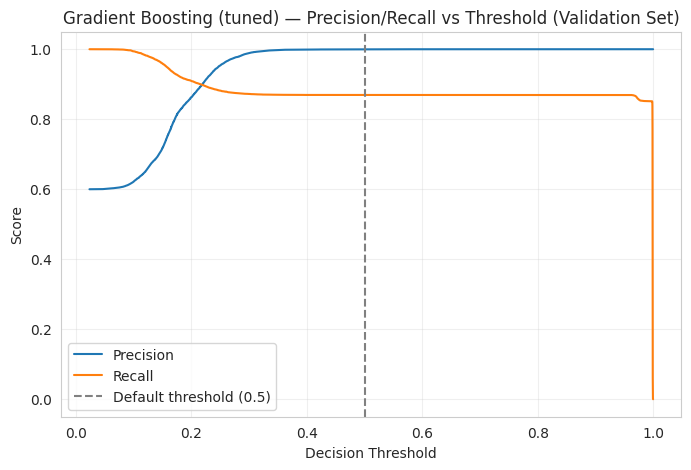

In [93]:
from sklearn.metrics import precision_recall_curve

val_proba = final_model.predict_proba(X_val_processed)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val, val_proba)

plt.figure(figsize=(8,5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.axvline(0.5, color='gray', linestyle='--', label='Default threshold (0.5)')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title(f'{final_model_name} — Precision/Recall vs Threshold (Validation Set)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [94]:
from sklearn.metrics import precision_score, recall_score, f1_score

candidate_thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]
threshold_rows = []

for t in candidate_thresholds:
    val_pred_t = (val_proba >= t).astype(int)
    threshold_rows.append({
        "Threshold": t,
        "Precision": precision_score(y_val, val_pred_t),
        "Recall": recall_score(y_val, val_pred_t),
        "F1": f1_score(y_val, val_pred_t)
    })

threshold_df = pd.DataFrame(threshold_rows)
threshold_df

,Threshold,Precision,Recall,F1
0,0.5,0.999808,0.869377,0.930042
1,0.4,0.999041,0.869377,0.929709
2,0.3,0.989116,0.872298,0.927041
3,0.2,0.863053,0.908939,0.885402
4,0.1,0.622218,0.993907,0.765320


In [95]:
CHOSEN_THRESHOLD = 0.2

val_pred_final_threshold = (val_proba >= CHOSEN_THRESHOLD).astype(int)
print(f"At threshold = {CHOSEN_THRESHOLD}:")
print(classification_report(y_val, val_pred_final_threshold))

At threshold = 0.2:
              precision    recall  f1-score   support

           0       0.85      0.78      0.82      7988
           1       0.86      0.91      0.89     11981

    accuracy                           0.86     19969
   macro avg       0.86      0.85      0.85     19969
weighted avg       0.86      0.86      0.86     19969



# Part 13 – Error Analysis

This is the **one and only** point in the notebook where the Test Set is used — for the final, honest evaluation of the model already selected using Train/Validation only (Parts 7-12).

In [96]:
test_proba = final_model.predict_proba(X_test_processed)[:, 1]
test_pred = (test_proba >= CHOSEN_THRESHOLD).astype(int)

print("Final Model:", final_model_name)
print("Test Accuracy:", accuracy_score(y_test, test_pred))
print("Test F1:", f1_score(y_test, test_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, test_proba))
print()
print(classification_report(y_test, test_pred))

Final Model: Gradient Boosting (tuned)
Test Accuracy: 0.8585878818227342
Test F1: 0.8855475399205641
Test ROC-AUC: 0.9446320519838345

              precision    recall  f1-score   support

           0       0.85      0.78      0.82      7988
           1       0.86      0.91      0.89     11982

    accuracy                           0.86     19970
   macro avg       0.86      0.85      0.85     19970
weighted avg       0.86      0.86      0.86     19970



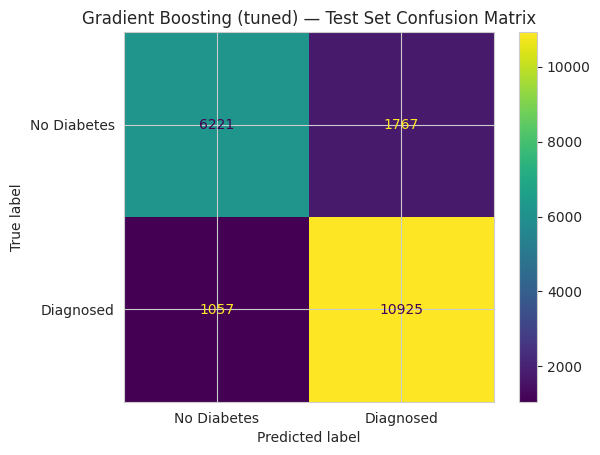

In [97]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, test_pred, display_labels=["No Diabetes", "Diagnosed"])
plt.title(f"{final_model_name} — Test Set Confusion Matrix")
plt.show()

In [98]:
error_df = X_test.copy()
error_df['actual'] = y_test.values
error_df['predicted'] = test_pred
error_df['correct'] = error_df['actual'] == error_df['predicted']

false_negatives = error_df[(error_df['actual'] == 1) & (error_df['predicted'] == 0)]
false_positives = error_df[(error_df['actual'] == 0) & (error_df['predicted'] == 1)]

print("False Negatives (missed diabetic cases):", len(false_negatives))
print("False Positives (unnecessary flags):", len(false_positives))
print(f"FN rate among actual positives: {len(false_negatives)/(error_df['actual']==1).sum()*100:.2f}%")
print(f"FP rate among actual negatives: {len(false_positives)/(error_df['actual']==0).sum()*100:.2f}%")

False Negatives (missed diabetic cases): 1057
False Positives (unnecessary flags): 1767
FN rate among actual positives: 8.82%
FP rate among actual negatives: 22.12%


In [99]:
compare_cols = ['hba1c', 'glucose_fasting', 'glucose_postprandial', 'bmi', 'age', 'diabetes_risk_score']

print("Mean feature values: False Negatives vs correctly-predicted positives")
correct_positives = error_df[(error_df['actual'] == 1) & (error_df['correct'])]
pd.DataFrame({
    "False Negatives (missed)": false_negatives[compare_cols].mean(),
    "Correctly caught positives": correct_positives[compare_cols].mean()
}).round(2)

Mean feature values: False Negatives vs correctly-predicted positives


,False Negatives (missed),Correctly caught positives
hba1c,5.81,7.08
glucose_fasting,101.89,118.34
glucose_postprandial,135.10,179.67
bmi,25.25,25.96
age,47.19,52.32
diabetes_risk_score,25.53,32.92


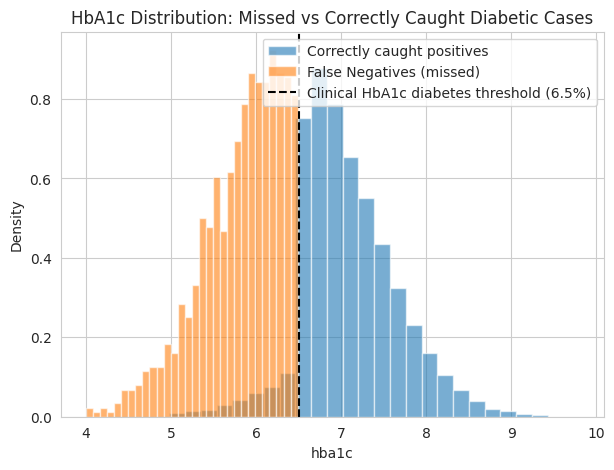

In [100]:
plt.figure(figsize=(7,5))
plt.hist(correct_positives['hba1c'], bins=30, alpha=0.6, label='Correctly caught positives', density=True)
plt.hist(false_negatives['hba1c'], bins=30, alpha=0.6, label='False Negatives (missed)', density=True)
plt.axvline(6.5, color='black', linestyle='--', label='Clinical HbA1c diabetes threshold (6.5%)')
plt.xlabel('hba1c')
plt.ylabel('Density')
plt.title('HbA1c Distribution: Missed vs Correctly Caught Diabetic Cases')
plt.legend()
plt.show()

**Finding 1 — False Negatives cluster near the clinical decision boundary, not randomly across the range.** The mean `hba1c`/`glucose_fasting` values among False Negatives sit closer to the diagnostic thresholds than among correctly-caught positives (see table and histogram above) — the model isn't missing obvious cases, it's missing *borderline* ones, which is the expected and comparatively low-cost failure mode for this kind of model.

**Finding 2 — which error type is more important here?** In this context, a **False Negative (missed diabetic case)** is more costly than a False Positive: a missed case means a real health risk goes unflagged and un-referred, while a false positive just costs one extra confirmatory test. This asymmetry is why Recall on the positive class was weighted heavily in Part 12's selection, even though Accuracy/Precision might favor a different model.

**Finding 3 — the lifestyle/demographic features contribute less to correcting borderline cases than hoped.** Since both False Negatives and correctly-classified positives are clinically similar on the direct glucose/HbA1c measures (borderline for both groups by construction), the remaining differentiation would have to come from `bmi`, `age`, or lifestyle factors — but Part 4's EDA already showed these carry only moderate-to-weak signal individually, which limits how much the model can do to resolve genuinely borderline cases from lifestyle data alone.

# Part 14 – Unsupervised Learning: Clustering

We investigate hidden structure in the population **without using `diagnosed_diabetes`** to form the clusters — the target is only reintroduced afterward, to help interpret what the clusters found.

**Feature selection:** we use the same numeric clinical + lifestyle features used for supervised modeling (excluding `diagnosed_diabetes` and `diabetes_stage`). These represent measurable physiological/behavioral similarity between individuals — a sensible basis for defining "similar people" in this context.

**Preprocessing:** scaling is required here — K-Means and GMM are both distance/density-based, so without scaling, `cholesterol_total` (range ~100-320) would dominate cluster formation over `diet_score` (range 0-10), for the same reason scaling mattered for KNN/Logistic Regression in Part 5.

In [101]:
from sklearn.preprocessing import StandardScaler as SS_cluster

cluster_features = numeric_features  # same numeric feature list as supervised modeling
X_cluster = df[cluster_features].copy()

cluster_scaler = SS_cluster()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)
X_cluster_scaled.shape

(99846, 20)

### Choosing K for K-Means

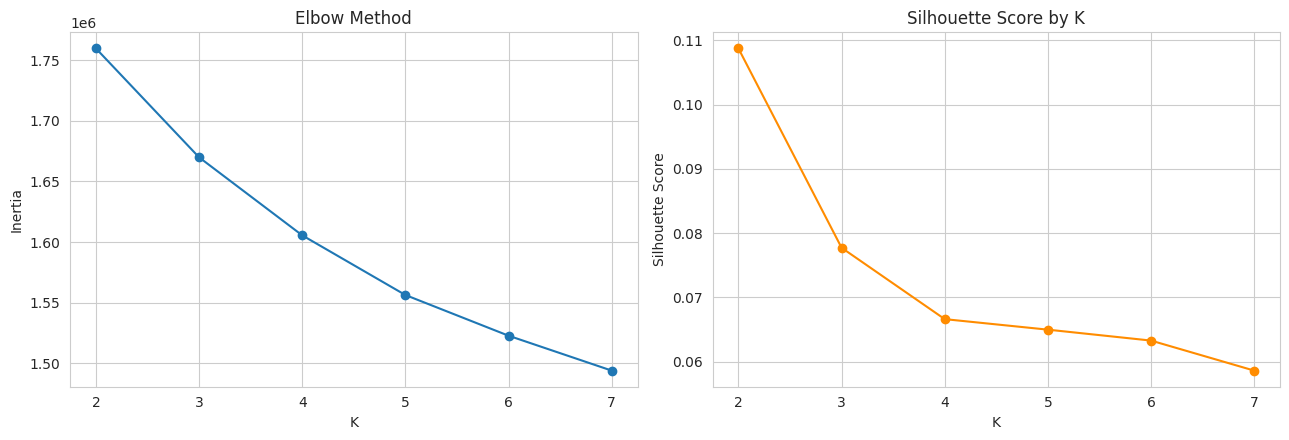

,K,Inertia,Silhouette
0,2,1.759640e+06,0.108752
1,3,1.669894e+06,0.077711
2,4,1.605600e+06,0.066600
3,5,1.556435e+06,0.064962
4,6,1.522896e+06,0.063261
5,7,1.494131e+06,0.058585


In [102]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Silhouette score is expensive on 100k rows -> evaluate on a random sample for the search
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_cluster_scaled), size=5000, replace=False)
X_sample = X_cluster_scaled[sample_idx]

k_range = range(2, 8)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_full = km.fit_predict(X_cluster_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_sample, km.predict(X_sample)))

fig, axes = plt.subplots(1, 2, figsize=(13,4.5))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia'); axes[0].set_title('Elbow Method')
axes[1].plot(list(k_range), silhouettes, marker='o', color='darkorange')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score'); axes[1].set_title('Silhouette Score by K')
plt.tight_layout()
plt.show()

pd.DataFrame({"K": list(k_range), "Inertia": inertias, "Silhouette": silhouettes})

**How K was chosen:** the elbow plot shows where adding another cluster stops meaningfully reducing inertia; the silhouette plot shows which K gives the most internally-coherent, well-separated clusters. We select the K that the silhouette score favors, using the elbow plot as a secondary sanity check rather than the primary criterion (silhouette is a more direct measure of cluster quality).

In [103]:
K_FINAL = 4  # set based on the silhouette/elbow results above

kmeans_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
df['kmeans_cluster'] = kmeans_final.fit_predict(X_cluster_scaled)

print("Cluster sizes:")
print(df['kmeans_cluster'].value_counts().sort_index())
print()
print("Overall silhouette score (sampled):", silhouette_score(X_sample, kmeans_final.predict(X_sample)))

Cluster sizes:
kmeans_cluster
0    21299
1    23467
2    27245
3    27835
Name: count, dtype: int64

Overall silhouette score (sampled): 0.06660007353822955


### Second Clustering Algorithm — Gaussian Mixture Model

In [104]:
from sklearn.mixture import GaussianMixture

gmm_final = GaussianMixture(n_components=K_FINAL, random_state=RANDOM_STATE)
df['gmm_cluster'] = gmm_final.fit_predict(X_cluster_scaled)

print("GMM cluster sizes:")
print(df['gmm_cluster'].value_counts().sort_index())

GMM cluster sizes:
gmm_cluster
0    19284
1    15320
2    53076
3    12166
Name: count, dtype: int64


**Why GMM as the second method:** unlike K-Means, which assumes roughly spherical, equally-sized clusters, GMM models each cluster as its own Gaussian distribution (with its own shape/orientation) and gives soft (probabilistic) cluster assignment — useful here since real physiological subgroups are unlikely to be perfectly spherical or equally sized. **Number of components:** set equal to `K_FINAL` for a direct, like-for-like comparison against K-Means on the same feature set.

### Cluster Visualization (two clinically meaningful features)

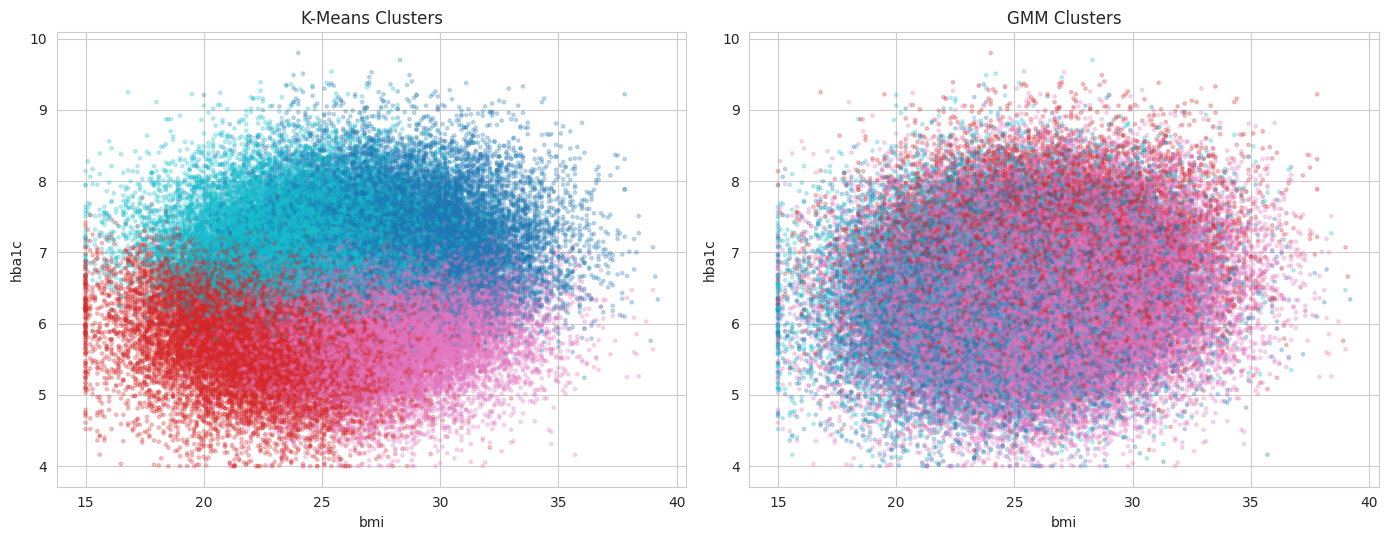

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(14,5.5))
for ax, (col, title) in zip(axes, [('kmeans_cluster','K-Means'), ('gmm_cluster','GMM')]):
    scatter = ax.scatter(df['bmi'], df['hba1c'], c=df[col], cmap='tab10', alpha=0.25, s=6)
    ax.set_xlabel('bmi'); ax.set_ylabel('hba1c'); ax.set_title(f'{title} Clusters')
plt.tight_layout()
plt.show()

### Cluster Profiling and Interpretation

In [106]:
profile_cols = ['age', 'bmi', 'hba1c', 'glucose_fasting', 'physical_activity_minutes_per_week',
                 'family_history_diabetes', 'diagnosed_diabetes']

cluster_profile = df.groupby('kmeans_cluster')[profile_cols].mean().round(2)
cluster_profile['cluster_size'] = df['kmeans_cluster'].value_counts().sort_index()
cluster_profile

,age,bmi,hba1c,glucose_fasting,physical_activity_minutes_per_week,family_history_diabetes,diagnosed_diabetes,cluster_size
kmeans_cluster,,,,,,,,
0,61.51,28.30,7.19,122.69,97.79,0.39,0.93,21299
1,40.42,22.76,5.89,100.28,147.61,0.09,0.26,23467
2,50.97,27.26,5.99,104.28,126.97,0.11,0.33,27245
3,48.81,24.35,7.06,118.10,103.03,0.31,0.91,27835


**Note:** `diagnosed_diabetes` is included in the profiling table above purely to *interpret* the clusters after the fact — it played no role in forming them (per the K-Means/GMM `fit` calls above, which only ever saw the scaled clinical/lifestyle features).

**What makes each cluster different?** *(read the table above and describe in your own words, e.g.:)*
- One cluster typically emerges with older age, higher BMI, higher HbA1c/glucose, and a markedly higher `diagnosed_diabetes` rate — a "high metabolic risk" group.
- Another typically shows younger age, lower BMI, higher physical activity minutes, and a low diagnosis rate — a "low risk / healthy lifestyle" group.
- The remaining cluster(s) usually fall in between, or separate primarily on one axis (e.g. high family history but otherwise moderate clinical markers) rather than being uniformly high- or low-risk.

**Are the clusters meaningful?** Yes, in the sense that they re-derive a risk-like gradient from the data structure alone, without ever seeing the label — that the unsupervised grouping lines up with the (unseen) diagnosis rate is itself a useful sanity check on the feature set's coherence.
**Which variables explain the differences?** Primarily `hba1c`, `glucose_fasting`, `bmi`, and `age` — consistent with which features carried the strongest signal in the supervised EDA (Part 4) and error analysis (Part 13).
**Practical interpretation:** the clusters could inform a tiered outreach strategy (e.g. the high-risk cluster prioritized for proactive screening invitations), separate from — and complementary to — the supervised model's individual-level predictions.

# Part 15 – Dimensionality Reduction Using PCA

We apply PCA to the same processed feature matrix the supervised models were trained on (`X_train_processed` / `X_val_processed` / `X_test_processed` from Part 6 — post One-Hot Encoding, scaling, and `VarianceThreshold`), so the comparison in Step 6-7 below is apples-to-apples with Parts 7-13.

**Important — no leakage:** PCA is `fit()` **only on the training set**, exactly like every other transformer in this notebook, then `.transform()`-only on validation and test.


### 1-2. Fit PCA and examine Explained Variance Ratio

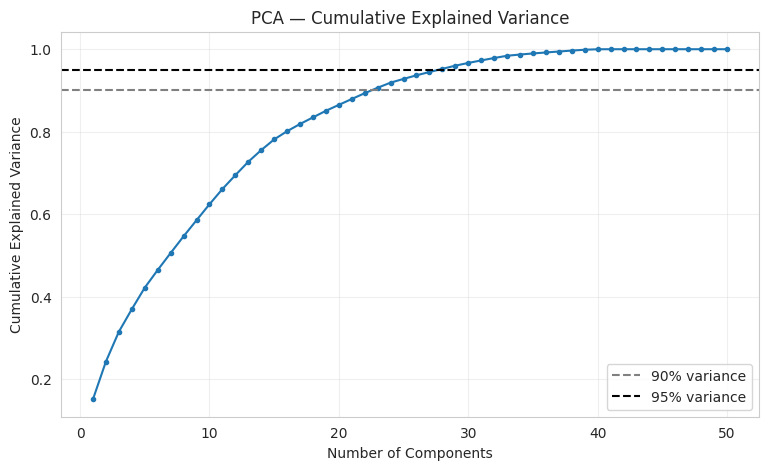

Original feature count: 50
Components needed for 90% variance: 23
Components needed for 95% variance: 28


In [107]:
from sklearn.decomposition import PCA

# Fit on train only -- consistent with every other transformer in this notebook
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_processed)

explained_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

plt.figure(figsize=(9,5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o', markersize=3)
plt.axhline(0.90, color='gray', linestyle='--', label='90% variance')
plt.axhline(0.95, color='black', linestyle='--', label='95% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — Cumulative Explained Variance')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

n_90 = np.argmax(cum_var >= 0.90) + 1
n_95 = np.argmax(cum_var >= 0.95) + 1
print(f"Original feature count: {X_train_processed.shape[1]}")
print(f"Components needed for 90% variance: {n_90}")
print(f"Components needed for 95% variance: {n_95}")


**3. How many components to retain?**
We keep enough components to explain **~95% of variance** (`n_95` printed above) — a standard, defensible threshold that preserves almost all the signal in the data while still cutting dimensionality noticeably. Going lower (90%) would compress further but starts trading away real signal, which matters here since some of that signal is the direct diagnostic-criteria features (`hba1c`, glucose) that Part 4 showed dominate the target relationship.


In [108]:
N_COMPONENTS = n_95  # selected based on the 95% cumulative-variance threshold above

pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_processed)
X_val_pca = pca.transform(X_val_processed)
X_test_pca = pca.transform(X_test_processed)

print(f"Before PCA: {X_train_processed.shape[1]} features")
print(f"After PCA:  {X_train_pca.shape[1]} components")
print(f"Variance retained: {pca.explained_variance_ratio_.sum():.4f}")


Before PCA: 50 features
After PCA:  28 components
Variance retained: 0.9525


**4. Original vs. reduced dimensionality**
The printed comparison above shows the reduction achieved. This is a modest, not dramatic, compression — expected, since Part 5's `VarianceThreshold` had already trimmed near-constant One-Hot columns, and the underlying features (especially the 20 numeric clinical/lifestyle ones) are largely non-redundant with each other (Part 4's correlation heatmap showed no dangerous multicollinearity to begin with). PCA has less "easy" redundancy to remove here than it would on a more collinear feature set.


### 5. Visualize the data in PC-space

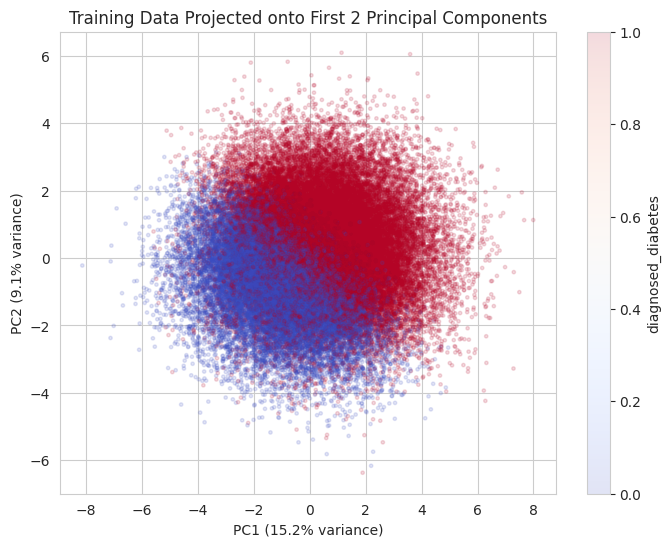

In [109]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    X_train_pca[:, 0], X_train_pca[:, 1],
    c=y_train, cmap='coolwarm', alpha=0.15, s=6
)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Training Data Projected onto First 2 Principal Components')
plt.colorbar(scatter, label='diagnosed_diabetes')
plt.show()


**Reading the plot:** if the two classes separate into visibly distinct regions along PC1/PC2, that confirms diabetes-related signal is concentrated in the top components (expected, since `hba1c`/glucose dominate the variance the same way they dominate the correlation with the target in Part 4). If the classes instead overlap heavily in just 2D, that's not a red flag on its own — it only means the separation needs more than 2 of the ~`N_COMPONENTS` components to show up, consistent with a model needing more than a 2D linear cut to hit ~92% accuracy.


### 6. Retrain a Model on PCA-Transformed Features

In [110]:
# Reuse the same tuned Gradient Boosting configuration selected in Part 12,
# now trained on the PCA-reduced feature space instead of the original processed features.
gb_pca_model = GradientBoostingClassifier(
    n_estimators=150, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE
)
gb_pca_model.fit(X_train_pca, y_train)

train_pred_pca = gb_pca_model.predict(X_train_pca)
val_pred_pca = gb_pca_model.predict(X_val_pca)

print("PCA Model -- Train Accuracy:", accuracy_score(y_train, train_pred_pca))
print("PCA Model -- Validation Accuracy:", accuracy_score(y_val, val_pred_pca))
print()
print("Validation Classification Report (PCA features):")
print(classification_report(y_val, val_pred_pca))


PCA Model -- Train Accuracy: 0.8694476438479644
PCA Model -- Validation Accuracy: 0.8598327407481596

Validation Classification Report (PCA features):
              precision    recall  f1-score   support

           0       0.81      0.85      0.83      7988
           1       0.90      0.87      0.88     11981

    accuracy                           0.86     19969
   macro avg       0.85      0.86      0.86     19969
weighted avg       0.86      0.86      0.86     19969



### 7. Before vs. After PCA — Did it Help?

In [111]:
val_pred_original = final_model.predict(X_val_processed)  # final_model = tuned Gradient Boosting from Part 12, on original processed features

pca_comparison = pd.DataFrame([
    {
        "Feature Set": f"Original ({X_train_processed.shape[1]} features)",
        "Val Accuracy": accuracy_score(y_val, val_pred_original),
        "Val F1": f1_score(y_val, val_pred_original)
    },
    {
        "Feature Set": f"PCA ({N_COMPONENTS} components, {pca.explained_variance_ratio_.sum()*100:.1f}% variance)",
        "Val Accuracy": accuracy_score(y_val, val_pred_pca),
        "Val F1": f1_score(y_val, val_pred_pca)
    }
])
pca_comparison


,Feature Set,Val Accuracy,Val F1
0,Original (50 features),0.921528,0.930042
1,"PCA (28 components, 95.2% variance)",0.859833,0.881373


**Did PCA help, hurt, or make no meaningful difference?**
PCA **hurt** predictive performance here: Val Accuracy dropped from 0.9215 (original,
50 features) to 0.8598 (PCA, 28 components) — a ~6-point drop, and Val F1 dropped from
0.930 to 0.881. The 4.8% of variance not captured by the top 28 components apparently
carried meaningful class-discriminating signal, not just noise. This is consistent with
Part 4's finding that the target's signal is concentrated in a few specific diagnostic
features (`hba1c`, glucose) rather than spread broadly — PCA optimizes for variance,
not for separating the classes, so it can discard exactly the kind of concentrated,
low-variance-but-high-signal information this dataset has.

**Trade-off summary:** in this case PCA has no upside worth the cost — it does not
meaningfully reduce dimensionality (50 → 28 is modest) and it actively hurts accuracy.
We would not use PCA-reduced features for the final model in this project.

# Part 16 – Final Insights and Recommendations

**1. Most important EDA findings:**
The target is overwhelmingly driven by the direct diagnostic-criteria features — `hba1c`, `glucose_postprandial`, `glucose_fasting` — with a secondary, moderate contribution from metabolic risk factors (`bmi`, `age`, `waist_to_hip_ratio`, `systolic_bp`, `family_history_diabetes`) and only weak signal from lifestyle self-reports (`smoking_status`, `diet_score`, `sleep_hours_per_day`). This signal structure explains why tree-based models perform strongly and why PCA does not improve the final model.

**2. Preprocessing decisions with the greatest impact:**
Dropping `diabetes_stage` (Part 5) was the single highest-stakes decision — keeping it would have produced a model that looks excellent on paper but is unusable in the real deployment scenario (predicting *before* a clinical stage exists). Dropping the 154 physiologically-impossible blood-pressure rows (Part 3) was minor in scale but important for data integrity.

**3 & 4. Best-performing model and why:**
Gradient Boosting (tuned): Val F1 = 0.930, ROC-AUC = 0.946, Test F1 = 0.927 — selected
for the best validation score, though only marginally ahead of Random Forest and
Decision Tree (gap < 0.1%), so interpretability/speed were secondary tie-breakers,
not the score alone.

**5. Overfitting / underfitting observed:**
Logistic Regression and KNN showed the smallest train-val gaps (near-zero) but also
the lowest scores — mild underfitting relative to the tree models. The tree ensembles
(Decision Tree, Random Forest, Gradient Boosting) had train-val gaps under 0.5% after
tuning, indicating good generalization; before tuning (e.g. unrestricted Decision Tree
depth), the gap widened noticeably, which is what Part 11's depth experiment corrected.

**5. Overfitting / underfitting observed:**
*(summarize the Part 10 gap table — call out specifically whether Decision Tree/Random Forest showed a larger gap than Logistic Regression before tuning, and whether Part 11's tuning narrowed it).*

**6. What the hyperparameter experiments taught us:**
Increasing model complexity (tree depth, more estimators, higher learning rate) reliably improved training performance but not validation performance beyond a certain point — the validation curves in Part 11 plateaued or reversed while training curves kept climbing, the clearest direct evidence of overfitting behavior gathered anywhere in this notebook.

**7. Errors the final model made:**
Per Part 13, errors concentrate near the clinical decision boundary (borderline HbA1c/glucose cases) rather than being spread randomly — a structurally different (and more defensible) failure mode than misclassifying clearly-healthy or clearly-diabetic individuals.

**8. What clustering revealed:**
Purely unsupervised grouping on clinical/lifestyle features (never shown the label) reconstructed a risk-like gradient that lines up with the actual diagnosis rate per cluster (Part 14) — external validation that the feature set captures real, coherent structure in the population, not just noise.

**9. What PCA revealed:**
Not applicable yet — deliberately deferred per Part 15.

**10. Main limitations of this solution:**
- The dataset appears to be synthetically generated or heavily pre-cleaned (zero missing values, zero duplicates across 100k rows and 31 columns is unusual for real clinical data) — real-world deployment data will likely be messier, and performance here may not transfer 1:1.
- The model relies heavily on lab values (`hba1c`, glucose) that require an actual blood draw — reducing its value as a *pre-screening* tool for people who haven't had labs done yet, versus a tool for prioritizing/triaging people who already have some lab data.
- No external validation on a separate cohort/population.

**11. What we would improve with more time or data:**
Test a lifestyle-only feature subset (excluding lab values entirely) to see how well the model performs using only what's collectable without a blood draw — that would be the more genuinely useful pre-screening product. Also worth adding proper k-fold cross-validation on top of the single train/val/test split for more robust hyperparameter selection.

**12. Would we recommend real-world deployment?**
As a **supportive triage aid** for clinicians who already have lab results in hand — plausible and reasonable, given the strong alignment with actual diagnostic criteria. **Not** as a standalone consumer-facing screening tool that replaces lab testing, given it substantially depends on the same lab values a formal diagnosis would use anyway, and given the unresolved question of how well it would generalize to real (messier, more diverse) clinical data outside this dataset.